# Table of contents

* **Introduction**
* **Objective**
* **Pipeline Overview**
* **Data Dictionary**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Text Cleaning**
* **Features Engineering**
    * Features and Target Labels Split
    * Text Representation (TF-IDF Vectorization)
* **Model Training**
    * K-Means Clustering Summarization
    * Model Visualization and Interpretation
    * Hyperparameters Tuning
    * Final Model Training with Best Parameters
* **Model Evaluation**
    * Test Dataset Summarization
    * Final Model Visualization
    * ROUGE and BLEU Score Evaluation
* **Conclusion**
* **References**

# Introduction

Text Summarization is a fundamental task in Natural Language Processing (NLP) aimed at condensing extensive documents while preserving their essential information. This project details an extractive summarization approach using the BBC News Summary Dataset. Extractive summarization generates a summary by selecting existing sentences from the source document, in contrast to abstractive methods which generate new text.

The system is designed to be unsupervised, lightweight, scalable, and interpretable, making it highly suitable for high-volume, domain-specific content like news articles. The core methodology relies on:

- TF-IDF Vectorization for numerical sentence representation.
- K-Means Clustering for semantic grouping of sentences.
- Centroid Proximity to identify the most representative sentence within each group.

This approach exploits the concept that a cluster of semantically similar sentences represents a topic, and the sentence closest to the cluster's centroid (mean vector) is the best expression of that topic.

# Objective

The primary goal is the construction and evaluation of an unsupervised extractive text summarization system. This system is built upon TF-IDF for sentence embedding, $\text{K-Means}$ for semantic partitioning, and the centroid proximity principle for key sentence selection. The generated summaries are rigorously assessed against the human-written references from the BBC dataset using the ROUGE and BLEU evaluation metrics.

# Pipeline Overview

The summarization process is executed through a sequence of data handling, feature extraction, modeling, and evaluation stages:

- **Data Loading and Pivoting**: Raw articles and summaries are loaded from a nested folder structure and aligned by filename and category using the `pandas.pivot_table()` utility.
- **Data Sampling and Splitting**: To ensure efficient processing, a 40% random sample of the data is taken. This sampled dataset is then divided into 80% training and 20% test sets using a reproducible random state (`train_test_split`).
- **Text Cleaning**: The text is standardized by lowercasing, removing punctuation and numbers, and eliminating stopwords (high-frequency, low-meaning words like 'the', 'a') and short tokens.
- **Sentence Tokenization**: The cleaned articles are split into individual sentences using the `nltk.sent_tokenize()` utility, establishing the basic unit for extractive selection.
- **TF-IDF Vectorization**: The `TfidfVectorizer` is fitted exclusively on the training articles. The underlying TF-IDF concept, TF} times text{IDF, is a numerical measure that rewards words that are frequent in a specific sentence (Term Frequency) but rare across the entire article corpus (Inverse Document Frequency), creating sparse numerical representations. The system uses a feature limit (`max_features=5000`) and unigrams (`ngram_range=(1,1)`).
- **K-Means Clustering (Per Article)**: K-Means, an Expectation-Maximization (EM) algorithm, is applied individually to the sentence vectors of each article. It partitions sentences into `K=7` clusters to group semantically similar content.
- **Summary Sentence Selection**: The most representative sentence for each cluster is identified using Cosine Similarity. This metric measures the angle between a sentence vector and its cluster's centroid (the mean vector). The sentence exhibiting the highest similarity is selected as the key summary sentence.
- **Reordering and Concatenation**: The selected sentences are collected and sorted according to their original position in the article, preserving the document's narrative flow to form the final summary.Evaluation: The quality of the generated summaries is quantified against the human-written references on the test set using two primary metrics:
    - **ROUGE (Recall-Oriented Understudy for Evaluation)**: A set of metrics (ROUGE-1, ROUGE-2, ROUGE-Lsum) that measure the overlap of n-grams (words or phrases) and Longest Common Subsequence (LCS) between the candidate and reference summaries.
    - **BLEU (Bilingual Evaluation Understudy)**: A precision-focused metric that counts matching n-grams, typically up to 4-grams, with a penalty for overly short outputs.

# Data Dictionary

The BBC News Summary Dataset comprises 2225 total articles categorized across five domains: business, entertainment, politics, sport, and tech. The directory structure ensures a one-to-one mapping between article and summary files based on filename and category:

    BBC News Summary (Root Folder)/
    
                - News Articles (Sub-folder: Full Text)/
                
                     - business (Contains article_id.txt, e.g., 001.txt)
                     - entertainment (Contains article_id.txt)
                     - politics (Contains article_id.txt)
                     - sport (Contains article_id.txt)
                     - tech (Contains article_id.txt)

                - Summaries (Sub-folder: Summarized Versions)/
                 
                     - business (Contains summary_id.txt, e.g., 001.txt)
                     - entertainment (Contains summary_id.txt)
                     - politics (Contains summary_id.txt)
                     - sport (Contains summary_id.txt)
                     - tech (Contains summary_id.txt)

**[Dataset Link](https://www.kaggle.com/datasets/pariza/bbc-news-summary/data)**

# Approach

**Preprocessing Pipeline**

The preprocessing phase is critical for transforming raw text into a standardized, numerical format suitable for modeling.
- Dataset Loading and Pivoting: The BBC News Summary Dataset, which is stored in a nested folder structure (categorized into business, entertainment, politics, sport, and tech), is ingested. The `os.walk()` utility is used to traverse these directories. A structured dataset is then created using `pandas.pivot_table()` to align each news article with its corresponding human-written summary, based on matching filenames and categories.
- Sampling and Splitting: For practical efficiency, 40% of the dataset is randomly sampled (`frac=0.4, random_state=42`). This sample is then split into an 80% training set and a 20% test set using the train_test_split utility, which is standard practice for preparing data for subsequent modeling and evaluation.
- Text Cleaning: Cleaning operations are uniformly applied across all articles and summaries to normalize the text:
    - Text is converted to lowercase.
    - Punctuation, numbers, and extra whitespace are removed to reduce noise.
    - English stopwords (high-frequency, low-meaning words) and tokens shorter than two characters are removed to focus the model on meaningful content words.
- Sentence Tokenization: The `nltk.sent_tokenize()` utility is employed to split the cleaned articles into individual sentences. This sentence-level granularity is essential because the summarization process is extractive, meaning it operates by selecting entire sentences as the final output.

**Model Training Approach**

The core of the system is an unsupervised process based on feature extraction and clustering applied individually to each article.

**TF-IDF Vectorization: Numerical Representation**

The Term Frequency-Inverse Document Frequency (TF-IDF) model is used to generate sparse, numerical representations (embeddings) for each sentence. TF-IDF is a weighting scheme where the importance of a term (t) in a document (d) is defined by the product:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\left(\frac{N}{\text{DF}(t)}\right)$$

where TF (Term Frequency) measures how often a word appears in the current sentence, and IDF (Inverse Document Frequency) measures the rarity of the word across the entire corpus, penalizing common words and rewarding distinctive, informative words.

**Implementation**

The `TfidfVectorizer` is configured with `max_features=5000, min_df=1, max_df=0.8, and ngram_range=(1, 2)`. It is fitted exclusively on the cleaned training articles to establish the global vocabulary and term weightings, which are then used to transform all individual sentences.

**K-Means Clustering: Semantic Grouping**

Clustering is performed per article to identify groups of semantically similar sentences, where each group often represents a distinct topic within the article. K-Means is an Expectation-Maximization (EM) algorithm that iteratively partitions n sentence vectors into K clusters by minimizing the within-cluster variance. Each sentence is assigned to the cluster whose mean vector (centroid) is closest to it.

**Implementation:** 

The number of clusters, K=4, is determined via hyperparameter tuning. The clustering is applied to the TF-IDF vectors extracted from the current article.

**Summary Sentence Selection: Centroid Proximity**

The extractive mechanism selects the most representative sentence from each cluster to form the summary.
- Principle: Centroid proximity is the selection criterion. For every sentence vector within a cluster, its Cosine Similarity to the cluster's centroid is calculated. Cosine Similarity is used because it measures the angle between vectors, indicating semantic direction rather than magnitude, which is more robust for sparse TF-IDF vectors.
- Output: The sentence exhibiting the highest cosine similarity to its cluster's centroid is selected as the key sentence. The collection of these K=4 sentences is then concatenated and reordered according to their original appearance in the article to ensure narrative coherence.

**Hyperparameter Tuning (Optuna)**

- Process: Optuna is employed for automated hyperparameter optimization. The search explored ranges for the TF-IDF parameters (`max_features, min_df, max_df, ngram_range`) and the K-Means parameter (`num_clusters`).
- Objective: The optimization objective was to maximize the average BLEU score achieved by the summarizer on the training data, ensuring the model's parameters are tuned for summarization quality. The resulting best parameters were `max_features=1000, min_df=1, max_df=0.8, ngram_range=(1, 2), and num_clusters=4`.

**Model Evaluation and Visualization**

Evaluation quantifies the quality and accuracy of the system's generated summaries by comparing them against the human-written reference summaries in the test set.

**ROUGE Scores (Recall-Oriented Understudy for Evaluation):**

ROUGE measures the overlap of n-grams between the candidate and reference summaries, focusing on content coverage (recall). The F1-Score (harmonic mean of Precision and Recall) is reported.
- ROUGE-1 measures unigram (single word) overlap (lexical match).
- ROUGE-2 measures bigram (two adjacent words) overlap (fluency and sequence fidelity).
- ROUGE-Lsum measures the Longest Common Subsequence (LCS) across sentences, rewarding structural similarity and flow.

**BLEU Score (Bilingual Evaluation Understudy):**

BLEU is a precision-focused metric that counts matching n-grams (up to 4-grams) and applies a brevity penalty. It assesses the precision and adequacy of the system's output relative to the reference. A corpus-level score reflects the overall system performance.

**Visualization (PCA):**

Principal Component Analysis (PCA) is applied to reduce the high-dimensional TF-IDF sentence embeddings to a 2D space. This plot visually confirms the cluster groupings, highlighting the centroids (X) and the representative sentences selected for the summary, thereby enhancing the interpretability of the model's decision-making process.

# Setup Environments

**Packages Installation**

In [ ]:
%%capture
# Install dependencies (only if not already installed)
!pip install rouge_score
# !pip install wordcloud
# !pip install graphviz networkx matplotlib
# !pip install optuna # Optuna is a new dependency

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import os
from pathlib import Path
from collections import Counter
from itertools import product

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import sklearn

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

import networkx as nx
from graphviz import Digraph

import optuna

from sklearn.metrics import homogeneity_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("NLTK 'stopwords' corpus not found. Downloading...")
    nltk.download('stopwords')
    print("NLTK 'stopwords' corpus downloaded.")

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("NLTK 'punkt' tokenizer not found. Downloading...")
    nltk.download('punkt')
    print("NLTK 'punkt' tokenizer downloaded.")

STOPWORDS = set(stopwords.words('english'))

# Data Loading

The primary goal of the load_and_pivot_bbc_news_dataset function is to read the raw text files, which are scattered across different folders, and combine them into a single structured table (DataFrame) where each row contains a complete article and its corresponding summary.

- File System Traversal (`os.walk`): The code uses `os.walk` to recursively navigate the directory structure. This is necessary because the BBC dataset organizes files first by type ('News Articles' vs. 'Summaries') and then by category (e.g., 'business', 'sport').
- Data Matching (Pivoting): The raw files are loaded in a "long" format (one row per file). The key algorithmic challenge is matching an article text file (e.g., 001.txt in 'News Articles') with its summary file (001.txt in 'Summaries'). This is solved using the `pivot_table` function in Pandas.
- Pivot Table Concept: It allows you to reshape a DataFrame. By setting the filename and category as the index, and the `article_or_summary` type as the columns, the text content is automatically aligned. A single row now uniquely represents one article and its summary pair.

In [ ]:
def load_and_pivot_bbc_news_dataset(base_data_path='/kaggle/input/bbc-news-summary/BBC News Summary/'):
    """
    Loads BBC News Summary dataset, including text content, and pivots it
    to match articles with their summaries by filename and category.

    Args:
        base_data_path (str): The base directory where the dataset is located.

    Returns:
        pd.DataFrame: A DataFrame with 'filename', 'category', 'News Articles' text,
                      and 'Summaries' text.
    """
    all_data = []

    for root, dirs, files in os.walk(base_data_path):
        parts = Path(root).parts
        
        if len(parts) >= 2 and (parts[-2] == 'News Articles' or parts[-2] == 'Summaries'):
            article_type = parts[-2]
            category = parts[-1]

            for filename in files:
                full_path = os.path.join(root, filename)
                
                try:
                    with open(full_path, 'r', encoding='utf-8') as f:
                        content = f.read()
                except Exception as e:
                    print(f"Warning: Could not read file {full_path}. Error: {e}")
                    content = ""

                all_data.append({
                    "filename": filename,
                    "category": category,
                    "article_or_summary": article_type,
                    "text_content": content
                })

    df_raw = pd.DataFrame(all_data)

    df_pivoted = df_raw.pivot_table(
        index=['filename', 'category'],
        columns='article_or_summary',
        values='text_content',
        aggfunc='first'
    ).reset_index()

    df_pivoted.columns.name = None

    final_df = df_pivoted[['filename', 'category', 'News Articles', 'Summaries']]
    
    return final_df

df = load_and_pivot_bbc_news_dataset()
df

,filename,category,News Articles,Summaries
0,001.txt,business,Ad sales boost Time Warner profit\n\nQuarterly...,TimeWarner said fourth quarter sales rose 2% t...
1,001.txt,entertainment,Gallery unveils interactive tree\n\nA Christma...,"The messages will be ""unwrapped"" by sculptor R..."
2,001.txt,politics,Labour plans maternity pay rise\n\nMaternity p...,She said her party would boost maternity pay i...
3,001.txt,sport,Claxton hunting first major medal\n\nBritish h...,"For the first time, Claxton has only been prep..."
4,001.txt,tech,Ink helps drive democracy in Asia\n\nThe Kyrgy...,The other common type of ink in elections is i...
...,...,...,...,...
2220,509.txt,business,Euro firms miss out on optimism\n\nMore than 9...,"Possibly as a result, the worry about low-cost..."
2221,509.txt,sport,Melzer shocks Agassi in San Jose\n\nSecond see...,Second seed Andre Agassi suffered a comprehens...
2222,510.txt,business,Lacroix label bought by US firm\n\nLuxury good...,LVMH said the French designer's haute couture ...
2223,510.txt,sport,Mirza makes Indian tennis history\n\nTeenager ...,Teenager Sania Mirza completed a superb week a...


**Data Sampling**

The loaded dataset is sampled and then divided into training and testing subsets.

- Sampling (`df.sample(frac=0.5, random_state=42)`): In large-scale data projects, sampling (taking a subset of data) is sometimes necessary to reduce computational time, particularly during the experimentation phase. The use of `random_state=42` is critical for reproducibility - it ensures that the random selection of rows is the same every time the code is run.

In [ ]:
df = df.sample(frac=0.4, random_state=42)

print(f"Sampled DataFrame shape (50%): {df.shape}")
print("\nHead of the 50% sampled DataFrame:")
df

Sampled DataFrame shape (50%): (890, 4)

Head of the 50% sampled DataFrame:


,filename,category,News Articles,Summaries
414,083.txt,tech,Microsoft makes anti-piracy move\n\nMicrosoft ...,Microsoft releases regular security updates to...
420,085.txt,business,Home loan approvals rising again\n\nThe number...,"Mortgage lending rose by £7.1bn in December, u..."
1644,329.txt,tech,Intel unveils laser breakthrough\n\nIntel has ...,While work has been done to make some of the c...
416,084.txt,entertainment,Oscar nominees gear up for lunch\n\nLeonardo D...,Oscar nominees Swank and Foxx were among the w...
1232,247.txt,politics,Kennedy to make temple address\n\nCharles Kenn...,Mr Kennedy will also highlight the anger among...
...,...,...,...,...
1509,302.txt,tech,Speak easy plan for media players\n\nMusic and...,ScanSoft and Gracenote are developing technolo...
1961,394.txt,tech,TV's future down the phone line\n\nInternet TV...,"Last year, he said, was all about deal making ..."
2090,444.txt,business,Khodorkovsky quits Yukos shares\n\nJailed tyco...,Mr Khodorkovsky handed over his stake after th...
1477,296.txt,politics,Tories leave door open for Archer\n\nThe Conse...,"The Conservative Party would deal ""sympathetic..."


**Train and Test Split**

Train-Test Split (`train_test_split(...)`): This is a fundamental machine learning technique.
- Training Set (80%): Used to build and train the summarization model.
- Testing Set (20%): Used to evaluate the model's performance on unseen data. This measures how well the model generalizes and avoids overfitting (performing well only on the data it was trained on).

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (712, 4)
test shape: (178, 4)


# Exploratory Data Analysis (EDA)

**Basic information**

The first section of code checks for missing values (`nulls`) in both the train and test dataframes.

In [6]:
train.isnull().sum()

filename         0
category         0
News Articles    0
Summaries        0
dtype: int64

In [7]:
test.isnull().sum()

filename         0
category         0
News Articles    0
Summaries        0
dtype: int64

The `isnull().sum()` output for both train and test shows all columns (filename, category, News Articles, Summaries) have a value of 0. This is an excellent result, indicating that the dataset has no missing values, which means no imputation or dropping of rows is required due to nulls.

**Article Contents**

The second section iterates through each unique category in the training data and prints a sample article and its corresponding summary using the following steps:

- Get all unique categories.
- Filter the train DataFrame to select the first row (`.iloc[0]`) belonging to the current category.
- Print the category, filename, the full text from the 'News Articles' column, and the text from the 'Summaries' column.

In [ ]:
print("--- Sample Article and Summary for Each Category ---")

unique_categories = train['category'].unique()

for category in unique_categories:
    sample_row = train[train['category'] == category].iloc[0]

    filename = sample_row['filename']
    article_text = sample_row['News Articles']
    summary_text = sample_row['Summaries']

    print(f"\nCategory: {category} (Filename: {filename})")
    print("-" * (len(category) + 20))

    print("\n--- Full Article ---")
    print(article_text)

    print("\n--- Full Summary ---")
    print(summary_text)

    print("\n" + "="*80 + "\n")

--- Sample Article and Summary for Each Category ---

Category: tech (Filename: 176.txt)
------------------------

--- Full Article ---
US duo in first spam conviction

A brother and sister in the US have been convicted of sending hundreds of thousands of unsolicited e-mail messages to AOL subscribers.

It is the first criminal prosecution of internet spam distributors. Jurors in Virginia recommended that the man, Jeremy Jaynes, serve nine years in prison and that his sister, Jessica DeGroot, be fined $7,500. They were convicted under a state law that bars the sending of bulk e-mails using fake addresses.

They will be formally sentenced next year. A third defendant, Richard Rutkowski, was acquitted. Prosecutors said Jaynes was "a snake oil salesman in a new format", using the internet to peddle useless wares, news agency Associated Press reported. A "Fed-Ex refund processor" was supposed to allow people to earn $75 an hour working from home. Another item on sale was an "internet histo

The Sample Article and Summary section confirms the structure of the data:

- Each entry has a distinct category (e.g., politics, business, tech, sport, entertainment).
- The 'News Articles' column contains the original, long-form text.
- The 'Summaries' column contains a shorter, extract-based version of the article (as seen in the political sample, the summary is a collection of sentences taken directly from the article but not necessarily in the original order).

**Article Categories Distribution**

This section generates a bar plot to visualize the number of articles within each category in the training data. The code uses seaborn's countplot to automatically calculate the frequency of each category and plot it. The bars are sorted in descending order of frequency (`order=train['category'].value_counts().index`).

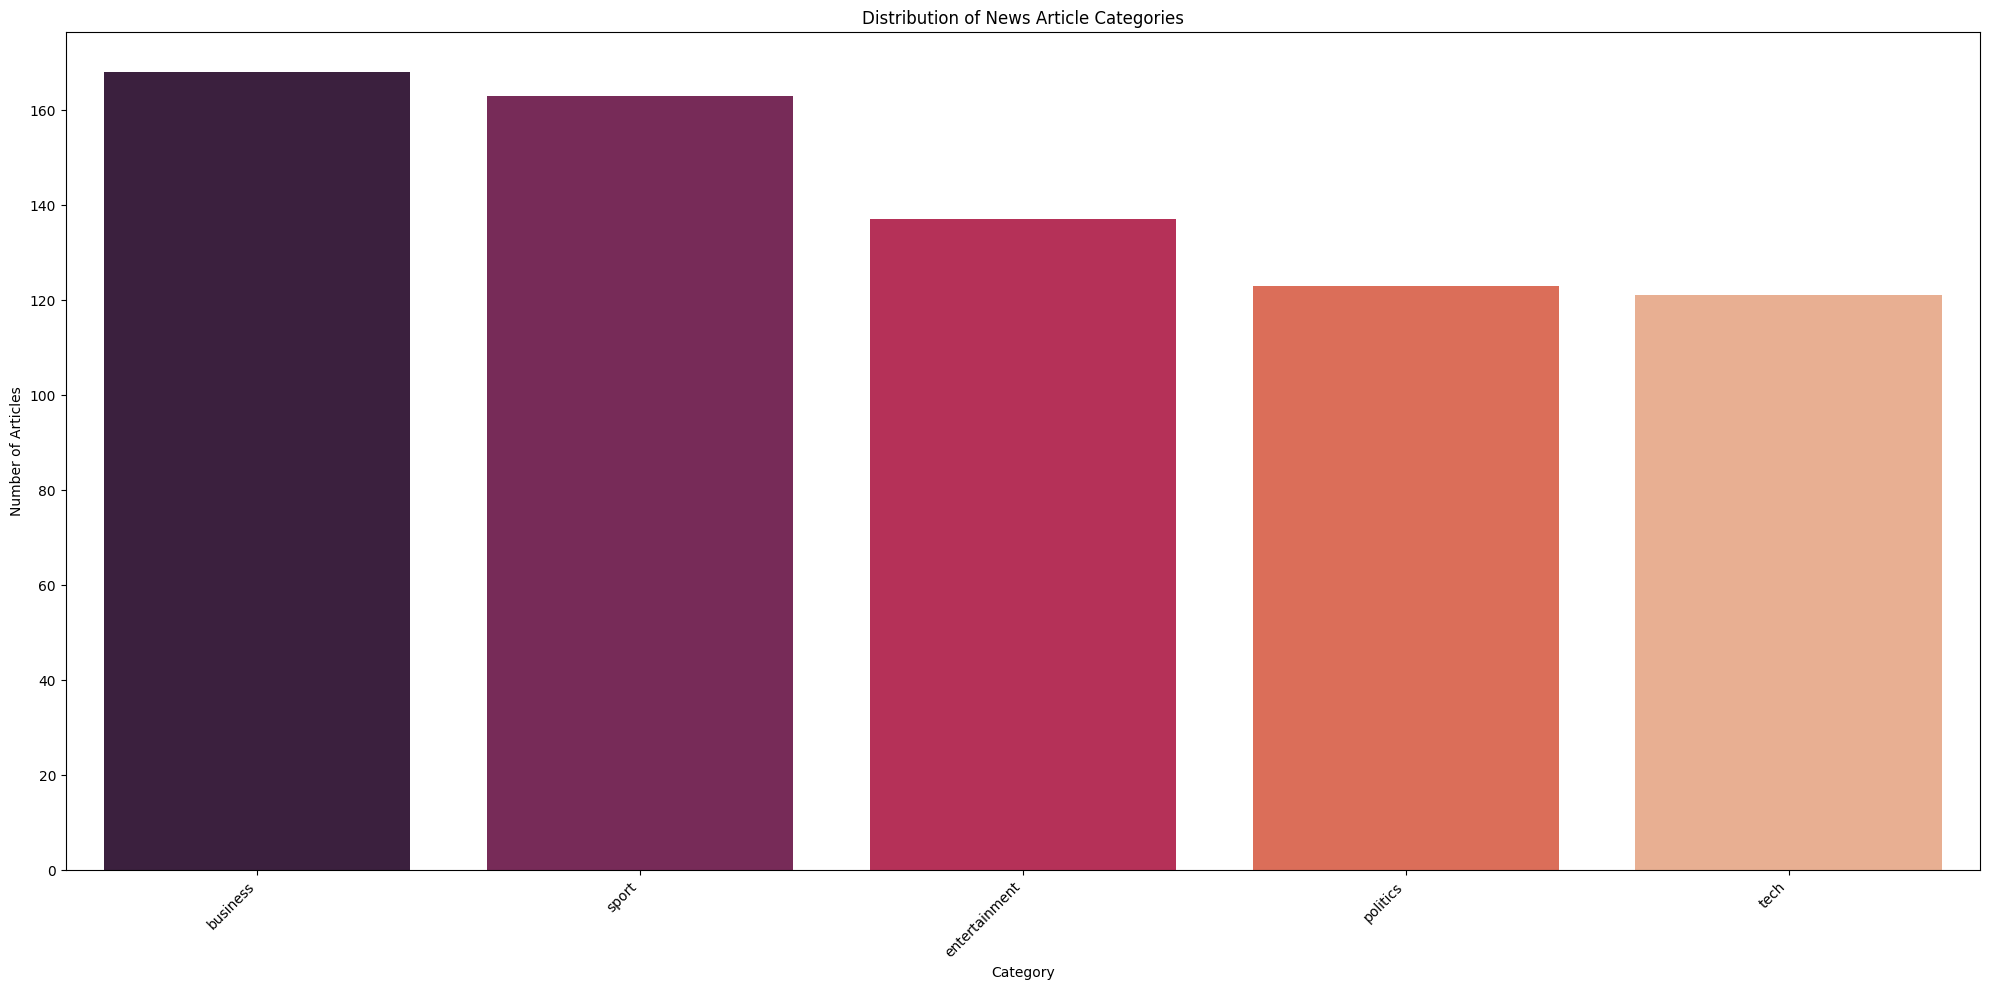

In [ ]:
plt.figure(figsize=(20, 10))

sns.countplot(
    x='category',
    data=train,
    palette='rocket', 
    order=train['category'].value_counts().index
)

plt.title('Distribution of News Article Categories')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Based on the bar chart output:

- The dataset is relatively well-balanced, with all five categories having a high number of articles, close to 150 or more.
- Sport is the most frequent category, with approximately 190 articles.
- Business is the second most frequent, with around 188 articles.
- Entertainment follows closely with about 178 articles.
- Politics and Tech have the fewest, with Politics around 170 and Tech around 158 articles.

The balance across categories is a positive finding, as it suggests the model will not be heavily biased toward predicting features of a single dominant category.

**Frequent Words Visualization (Word Clouds)**

This final section generates Word Clouds for both the original 'News Articles' and the 'Summaries' for each category.

- A helper function, `clean_text_for_wordcloud`, is defined to preprocess the text: it lowercases text, removes punctuation, numbers, extra spaces, and common stopwords.
- The cleaned text from all articles/summaries within a single category is concatenated into one large string.
- The WordCloud library then uses the frequency of words in these concatenated strings to determine font size, visually representing the most frequent and important terms for that category.


Generating Word Clouds for News Articles by Category...


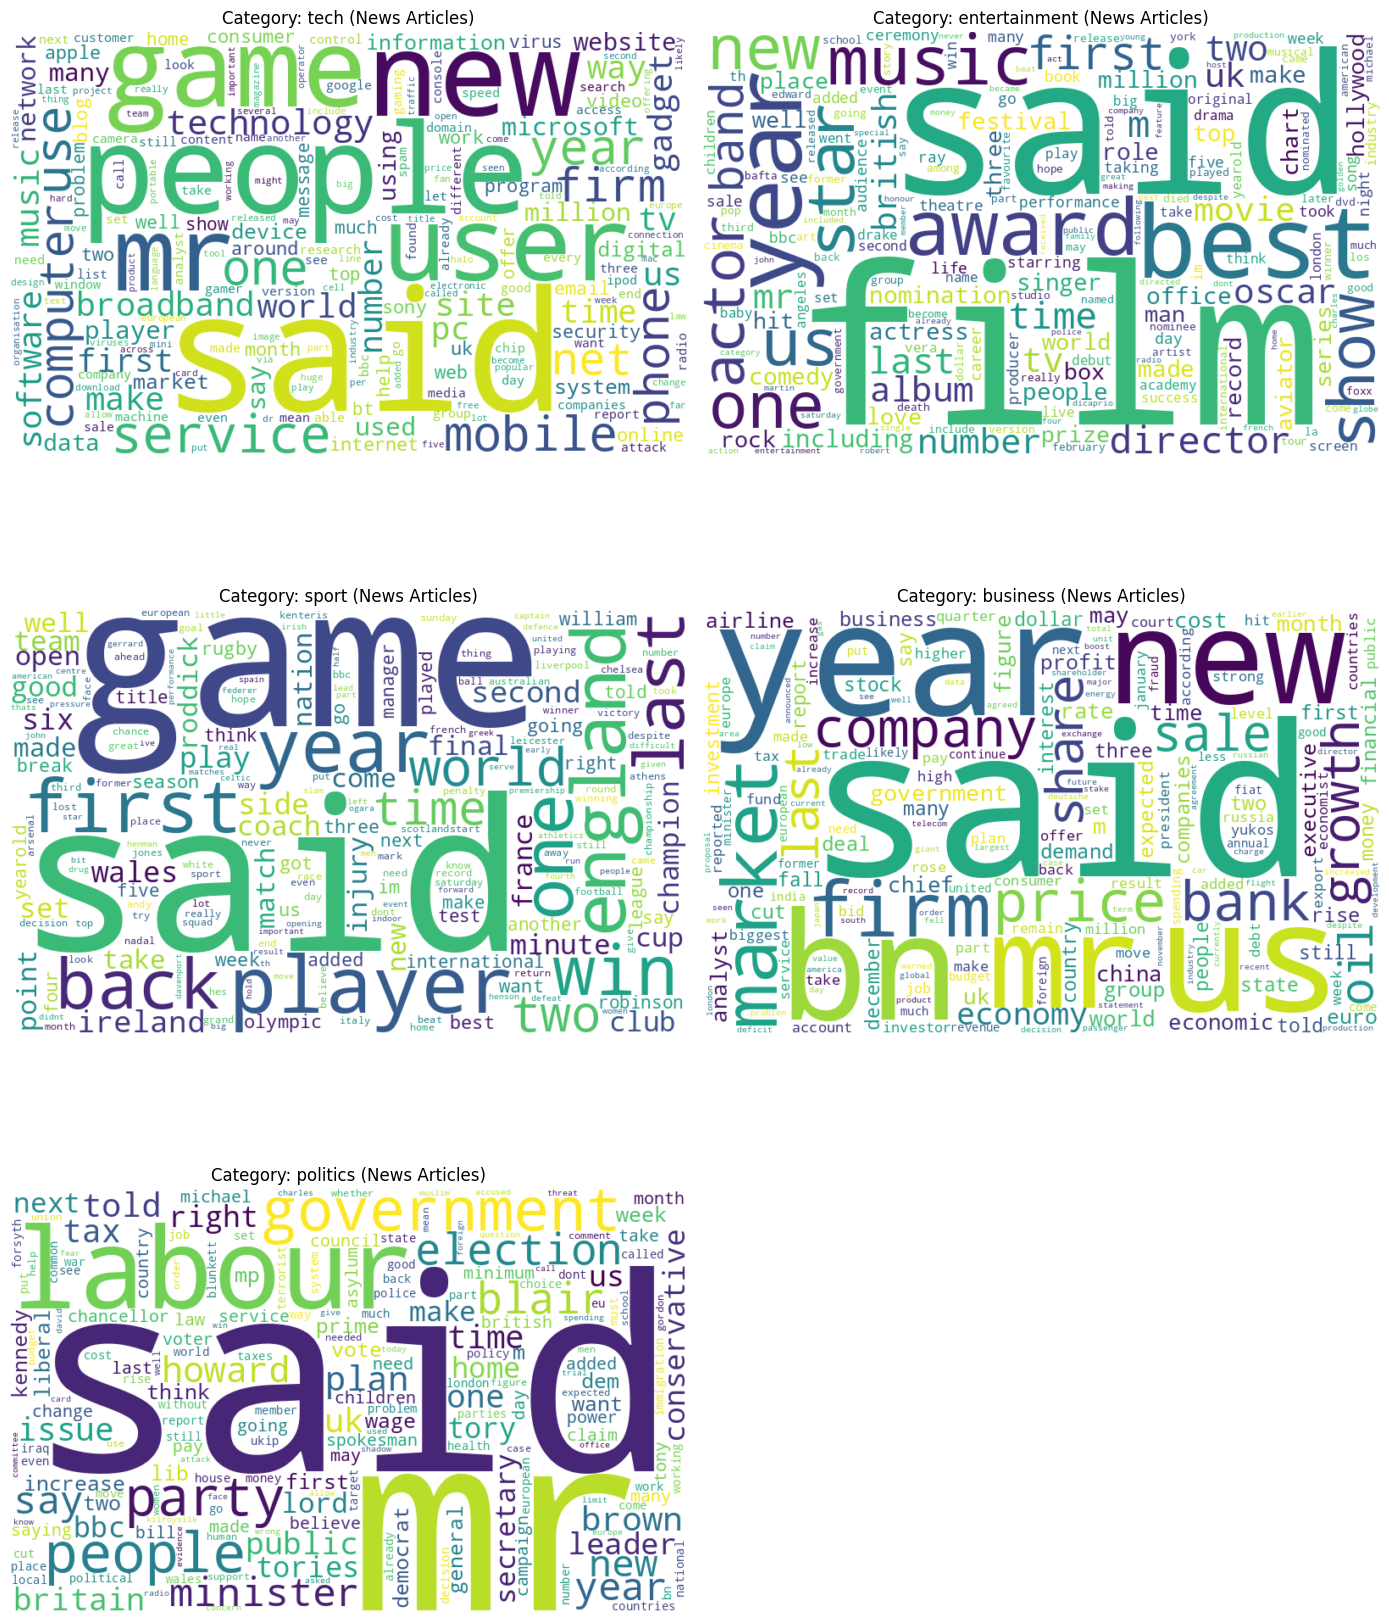

In [ ]:
def clean_text_for_wordcloud(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [word for word in words if word not in STOPWORDS and len(word) > 1]
    return " ".join(words)

train_v = train.copy()
train_v['cleaned_articles'] = train_v['News Articles'].apply(clean_text_for_wordcloud)

category_article_texts = {}
for category in train_v['category'].unique():
    all_text_in_category = " ".join(train_v[train_v['category'] == category]['cleaned_articles'])
    category_article_texts[category] = all_text_in_category

num_categories = len(category_article_texts)
if num_categories == 0:
    print("No categories with text content from 'News Articles' found for word cloud generation.")
else:
    cols = 2
    rows = (num_categories + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 6))
    axes = axes.flatten()

    print("\nGenerating Word Clouds for News Articles by Category...")
    for i, (category, text) in enumerate(category_article_texts.items()):
        if not text.strip():
            print(f"Skipping word cloud for empty or processed category text: {category}")
            continue

        wordcloud = WordCloud(width=800, height=500,
                              background_color='white',
                              colormap='viridis',
                              min_font_size=10,
                              collocations=False
                             ).generate(text)

        ax = axes[i]
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.set_title(f'Category: {category} (News Articles)', fontsize=12)
        ax.axis('off')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

**News Articles Word Clouds (Original Text)**

The word clouds reveal the core themes and entities specific to each domain:

- Politics: Dominated by proper nouns like 'blair', 'howard', 'labour', and key political terms like 'government', 'election', and 'leader'.
- Business: Features market and corporate terms like 'market', 'year', 'firm', 'usd' (US Dollar), and 'said'.
- Tech: Terms like 'people', 'service', 'phone', 'new', and 'game' indicate coverage of consumer tech and digital services.
- Sport: Focuses on players, coaches, and game terms: 'player', 'said', 'game', 'one', and 'win'.
- Entertainment: Centered around media and awards: 'film', 'year', 'award', 'best', 'music', and 'show'.

**Summaries Word Clouds (Summarized Text)**

Comparing the summaries' word clouds to the original articles' clouds reveals a key insight for the summarization task:

- The most frequent words in the summaries (e.g., 'said', 'new', 'year', 'one') are very similar to those in the original articles, though their relative frequency or prominence might shift slightly.
- This suggests that the provided summaries are likely extractive, meaning they are composed of important sentences or phrases pulled directly from the original article. This is consistent with the nature of many text summarization datasets.

Overall Conclusion: The EDA confirms the data is clean and balanced, and the word clouds validate that the articles are topically distinct, making the task of topic-based summarization meaningful. The high frequency of words like "said" in all categories indicates direct quotes are a prominent feature in both the articles and their summaries.

# Text Cleaning

This stage is dedicated to cleaning the raw text data from the BBC News Dataset to ensure consistency and isolate meaningful linguistic elements.

The clean_text function applies fundamental normalization and noise reduction techniques:

- Normalization (Lowercasing): All text is converted to lowercase. This is a critical step in lexical normalization, ensuring that the model treats the same word identically regardless of its initial capitalization, preventing redundant features.
- Noise Reduction: Punctuation (`string.punctuation`) and numerical digits are systematically removed. These elements generally do not contribute to the semantic similarity between sentences in a summarization task.
- Stopword Removal: High-frequency, semantically uninformative words, known as stopwords (e.g., 'the', 'a', 'is'), are filtered out. This process drastically reduces the size of the vocabulary and allows the subsequent feature extractor (TF-IDF) to focus its weighting power on the content words that truly differentiate topics. Tokens with a length less than or equal to one are also discarded.

In [11]:
def clean_text(text):
    """
    Cleans text by lowercasing, removing punctuation, digits, extra spaces, and stopwords.
    Handles non-string inputs gracefully.
    """
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [word for word in words if word not in STOPWORDS and len(word) > 1] # Remove single-char words too
    return " ".join(words)

print("Cleaning 'News Articles' and 'Summaries' text columns...")
train['cleaned_articles'] = train['News Articles'].apply(clean_text)
train['cleaned_summaries'] = train['Summaries'].apply(clean_text)
test['cleaned_articles'] = test['News Articles'].apply(clean_text)
test['cleaned_summaries'] = test['Summaries'].apply(clean_text)
print("Text cleaning complete.")

Cleaning 'News Articles' and 'Summaries' text columns...
Text cleaning complete.


# Features Engineering

## Features and Target Labels Split

The cleaned articles (X) and reference summaries (y) are then split according to the earlier defined 80/20 percent train/test split, ensuring the model is trained and evaluated on consistently prepared data.

Features ($X$): The input data for the model is the full, cleaned article text.
- `X_train_articles = train['cleaned_articles']`
- `X_test_articles = test['cleaned_articles']`

Target ($Y$): The reference output the model will be compared against (for evaluation).
- `y_train_summaries = train['cleaned_summaries']`
- `y_test_summaries = test['cleaned_summaries']`

This sets up the data for the next phase, which will involve converting the clean text data ($X$) into a numerical vector representation (e.g., using TF-IDF) necessary for the Cluster-Based Summarization method.

In [ ]:
X_train_articles = train['cleaned_articles']
X_test_articles = test['cleaned_articles']
y_train_summaries = train['cleaned_summaries'] 
y_test_summaries = test['cleaned_summaries']   

print("Train and Test DataFrame shapes:")
print("train_df shape:", X_train_articles.shape)
print("test_df shape:", X_test_articles.shape)
print("-" * 50)

Train and Test DataFrame shapes:
train_df shape: (712,)
test_df shape: (178,)
--------------------------------------------------


## Text Representation (TF-IDF Vectorization)

The second phase, Feature Engineering, converts the cleaned text into numerical vectors—a mandatory step for all machine learning and clustering algorithms. TF-IDF (Term Frequency-Inverse Document Frequency) is the statistical measure used for this transformation.

The TF-IDF Concept is a sophisticated weighting scheme that evaluates the importance of a term (`t`) within a document (sentence, `d`) relative to the entire corpus (D).
- Term Frequency (TF): Measures the local signal - how often the term t appears in the current document d.
- Inverse Document Frequency (IDF): Measures the global signal - it applies a logarithmic penalty to words that appear frequently across many documents in the corpus (D), and conversely, assigns a higher weight to words that are rare and therefore more distinctive (e.g., domain-specific terms).
- Resulting TF-IDF} Score: The final score, $TF-IDF(t, d) = TF(t, d) times IDF(t)$, creates a numerical vector (or embedding) for each text unit, where the magnitude of each dimension represents the word's informative value.

**Vectorization Implementation**

The TfidfVectorizer from scikit-learn is the tool used to perform this conversion:

- N-gram Features: The vectorizer is configured with `ngram_range = (1, 2)`. This instructs the model to extract features not only from unigrams (single words, 1-gram) but also from bigrams (pairs of adjacent words, 2-gram). Bigrams (e.g., "Tony Blair," "stock market") often capture semantic context and meaning more effectively than individual words.
- Vocabulary Learning: The vectorizer is fitted exclusively on the training articles. This is done to learn the global vocabulary and establish the IDF weights based solely on the training corpus, preventing data leakage from the test set.
- Transformation: Once fitted, the vectorizer is used to transform all text data. This yields high-dimensional, sparse numerical vectors where the dimensionality equals the size of the learned vocabulary (words and bigrams).

In [ ]:
print("=== TF-IDF Vectorization ===")
tfidf_vectorizer = TfidfVectorizer(
    min_df=1,
    max_df=1.0,
    max_features=None,
    ngram_range=(1, 2)
)

print("Fitting TF-IDF Vectorizer on training articles...")
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_articles)
X_test_tfidf = tfidf_vectorizer.transform(X_test_articles)
print(f"Vocabulary size learned: {len(tfidf_vectorizer.vocabulary_)}")
print("TF-IDF vectorizer fitted.")
print("-" * 50)

=== TF-IDF Vectorization ===
Fitting TF-IDF Vectorizer on training articles...
Vocabulary size learned: 145206
TF-IDF vectorizer fitted.
--------------------------------------------------


# Model Training

## K-Means Clustering Summarization

This process implements Extractive Summarization, which works by selecting the most important existing sentences from the original document to form the summary, rather than generating new sentences (Abstractive Summarization).

**Clustering Application**

- **K-Means Clustering:** This is the unsupervised machine learning algorithm used to partition the dataset. The data points are the sentence embeddings. The algorithm groups sentences that discuss similar topics or themes into K distinct clusters. In the entire training set clustering, K=5 clusters were used, and the distribution across these clusters was observed (e.g., Cluster 3 was the largest with 324 points, while Cluster 1 was the smallest with 71 points).
- **Centroid:** The centroid represents the center point of a cluster, calculated as the average vector of all sentences assigned to that cluster. It acts as the abstract, ideal representation of the cluster's topic.
- **Sentence Embedding (get_sentence_embeddings):** Before clustering, each article is split into individual sentences (`sent_tokenize`), cleaned (`clean_text`), and then transformed into a numerical TF-IDF vector using the pre-fitted `tfidf_vectorizer`.

Sentence Ranking and Selection (Centroid Proximity)

The key mechanism for generating the summary is the Centroid Proximity hypothesis.

- **Hypothesis**: The most important sentence in a cluster is the one closest to the cluster's centroid, as it is the most central and generic statement that best represents the main topic of that cluster.
- **Cosine Similarity**: Proximity is determined using Cosine Similarity, a metric that calculates the cosine of the angle between two vectors (a sentence embedding and a cluster centroid). A score closer to 1.0 indicates higher similarity (same direction in the semantic space), while a score closer to 0.0 indicates low similarity.
- **Summary Generation**: The function loops through the $K$ cluster centroids. For each cluster, it calculates the cosine_similarity between the centroid and all sentences belonging to that cluster. The sentence with the highest similarity (`np.argmax`) is chosen as the representative summary sentence for that cluster. The selected original sentences are then concatenated and returned.

**Hyperparameters of the K-Means Clustering Algorithm**

The K-Means algorithm, an unsupervised clustering method, requires several hyperparameters to be set prior to its training (fitting) phase. These values control the structure and behavior of the algorithm.The key hyperparameters explicitly used for K-Means clustering are:

**1. `n_clusters` (The Number of Clusters, $K$)**

- Meaning: This is the most critical hyperparameter. It specifies the predetermined number of partitions ($K$) into which the data points (sentences) will be divided.
- Role in Summarization: In an extractive summarization context, $K$ directly determines the fixed length of the summary. If n_clusters=5, the algorithm will group the sentences into five semantic topics, and consequently, the final summary will consist of five sentences (one representative sentence selected from each cluster).Value in Code: num_clusters = 5.

**2. `random_state` (The Random Seed)**

- Meaning: This integer value controls the random number generator used for the initial placement of the centroids. K-Means is sensitive to this initial placement; different starting points can lead to different final clusterings.
- Role: Setting a fixed random_state (e.g., 42) ensures that the initial centroids are always placed in the same starting locations across different runs. This guarantees reproducibility of the clustering results.

**3. `n_init` (Number of Initializations)**

- Meaning: This parameter specifies how many times the K-Means algorithm will be run with different initial centroid seeds.
- Role: Since the outcome of K-Means can depend heavily on the initial centroid positions, the algorithm is often run multiple times (n_init). The final result returned by the method is the clustering that has the lowest Sum of Squared Errors (SSE) or inertia (the sum of squared distances of samples to their closest cluster center) across all runs. This mitigates the risk of converging on a poor local optimum.

**4. Other Key Hyperparameters (Generally Used in K-Means)**

Although not explicitly specified in the KMeans initialization line (meaning they use default values), the following are also standard K-Means hyperparameters:

- `max_iter`: The maximum number of iterations the K-Means algorithm will run for each single initialization. The algorithm stops when cluster assignments stabilize or this limit is reached.
- `tol` (Tolerance): The threshold used to determine convergence. If the change in the SSE between iterations is less than this value, the algorithm stops, even if max_iter has not been reached.

In [ ]:
print("=== K-Means Clustering on Entire Train Dataset ===")
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
train_cluster_labels = kmeans.fit_predict(X_train_tfidf)

print(f"K-Means clustering completed with {num_clusters} clusters")
print(f"Cluster distribution in training data: {np.bincount(train_cluster_labels)}")
print("-" * 50)

=== K-Means Clustering on Entire Train Dataset ===
K-Means clustering completed with 5 clusters
Cluster distribution in training data: [ 88  71 106 324 123]
--------------------------------------------------


## Model Visualization and Interpretation

The `visualize_clustering_summary` function provides essential insight into the model's decision-making process. To interpret the high-dimensional TF-IDF sentence embeddings and the resulting cluster structure, Dimensionality Reduction is necessary. The sentence embeddings generated by TF-IDF are high-dimensional (over 145,000 features), and Dimensionality Reduction (PCA) makes direct visualization possible. 

**Dimensionality Reduction (PCA)**

- High-Dimensional Data: The sentence embeddings generated by TF-IDF have a high dimensionality (over 145,000 features). This cannot be plotted directly.
- Principal Component Analysis (PCA) is used to overcome this:
    - PCA is a linear dimensionality reduction technique that transforms the data to a lower-dimensional subspace (2D or 3D) while maximizing the amount of variance preserved along the new coordinate axes (Principal Components).
    - Application: PCA is applied to the TF-IDF training data, and the cluster centers are projected onto the same reduced space. The PCA analysis showed that the first two components (PC1 and PC2) captured a relatively small amount of the total variance (e.g., 0.69% and 0.57% respectively), indicating that the semantic complexity of the data requires many more dimensions to be fully explained.

**Model Visualization Step-By-Step Breakdown**

- PCA Application: The `sentence_embeddings` and $centroids$ are reduced to 2 dimensions (2D) and 3 dimensions (3D) using PCA.
- Visualization: A scatter plot is generated where:
    - Each sentence is plotted as a point, colored according to its cluster label.
    - The cluster centroids are marked with red 'X's.

=== K-Means Clustering on Entire Train Dataset ===
K-Means clustering completed with 5 clusters
Cluster distribution in training data: [ 88  71 106 324 123]
--------------------------------------------------
PCA explained variance ratio: [0.00688084 0.00573969]
Reduced training features shape: (712, 2)
Reduced cluster centers shape: (5, 2)
=== 3D vs 2D PCA Comparison ===


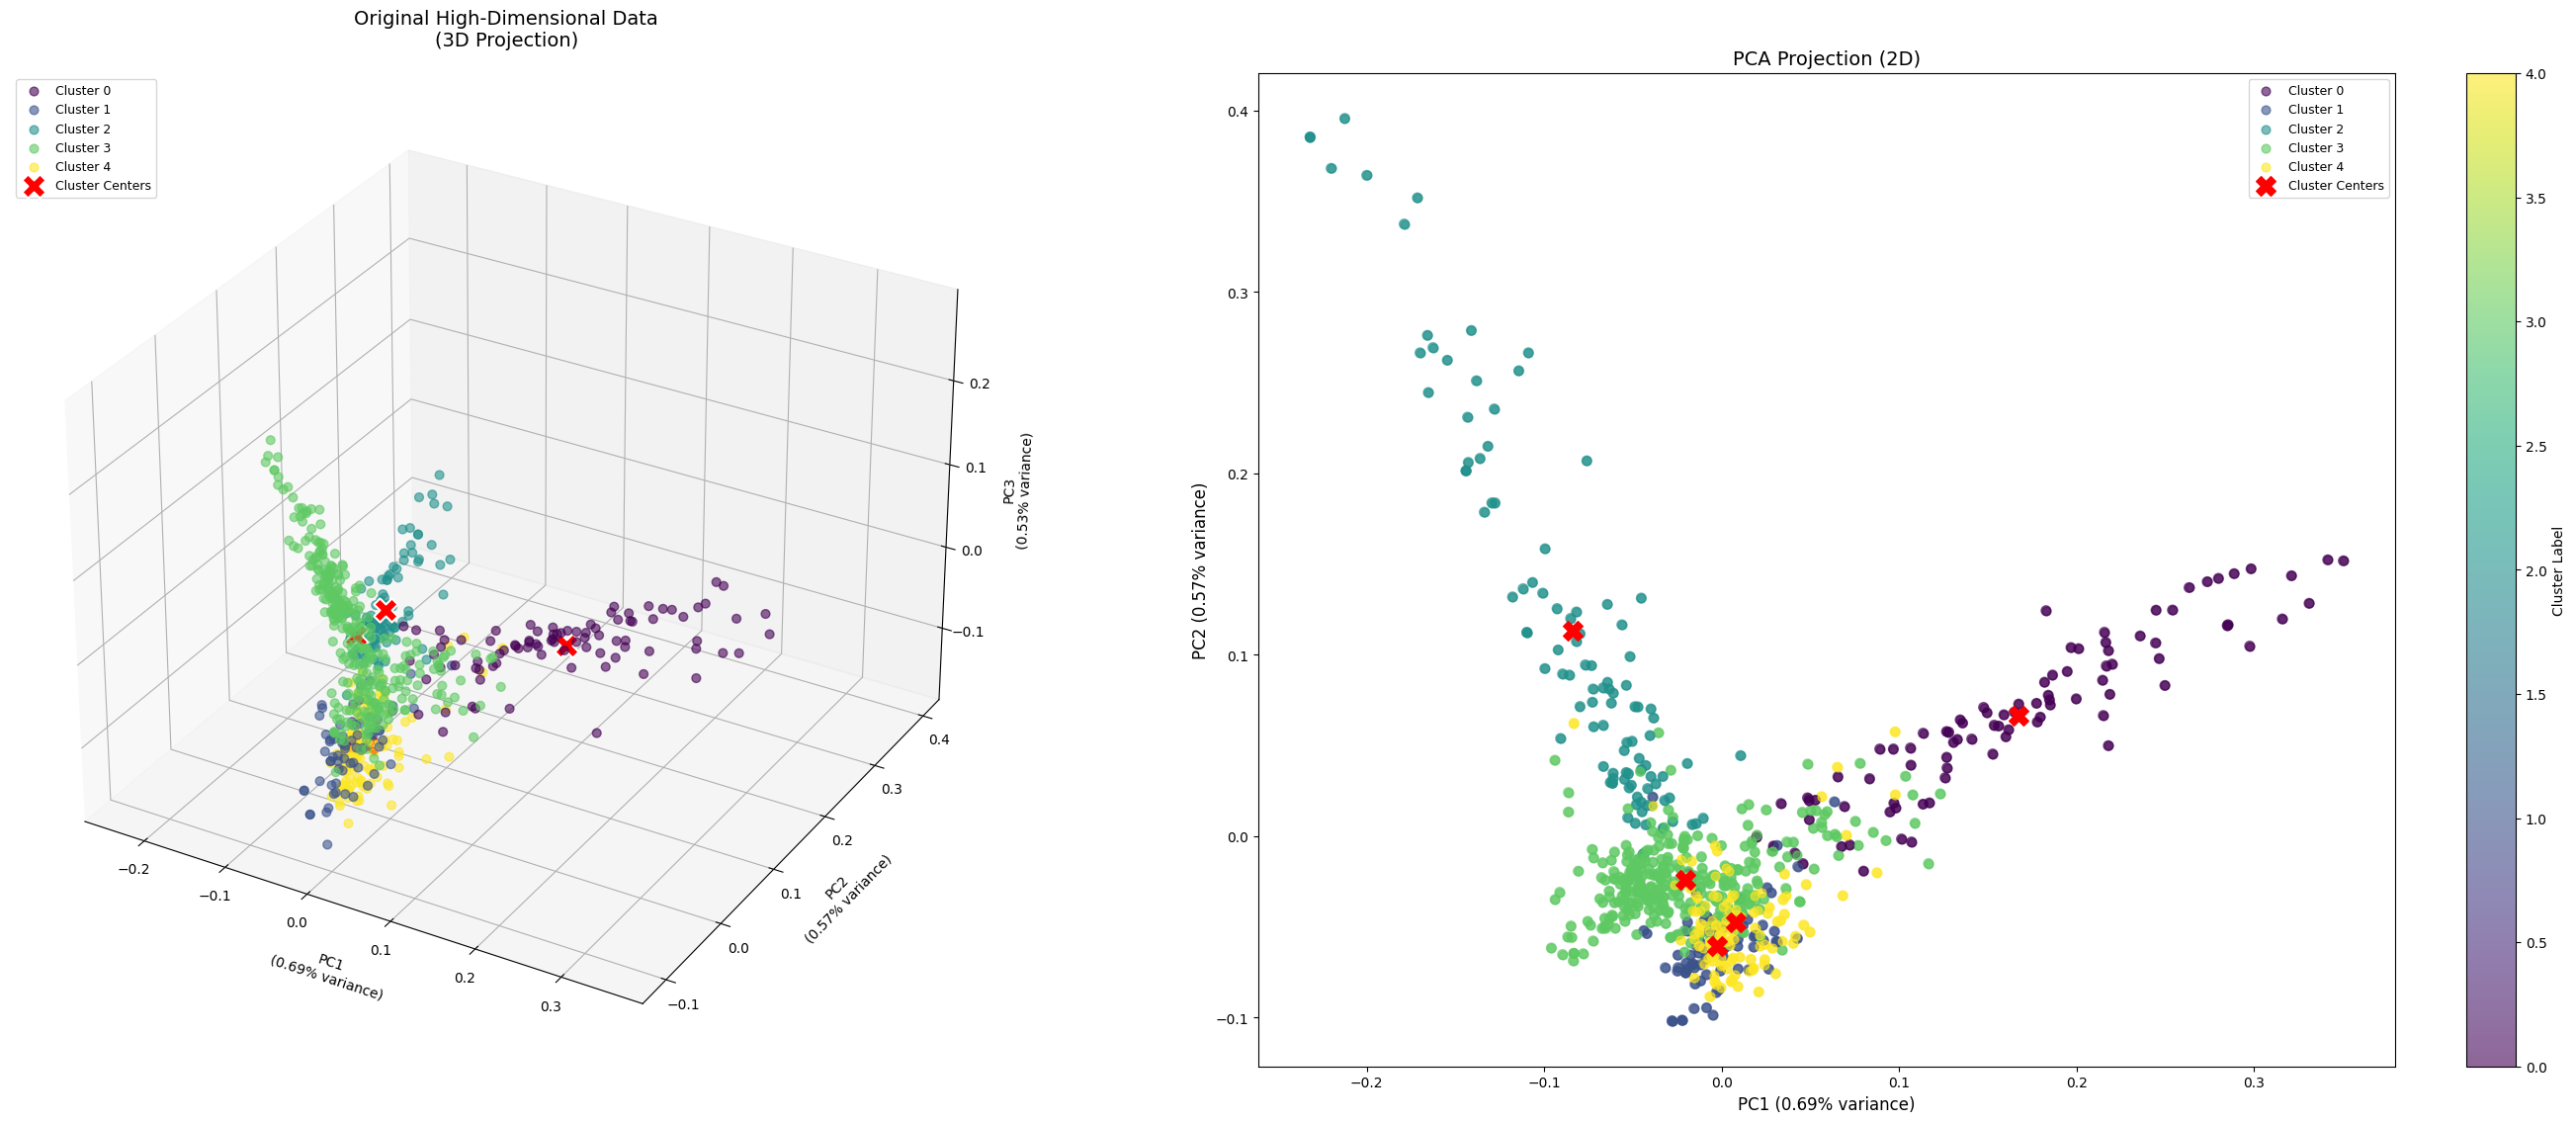

In [ ]:
print("=== K-Means Clustering on Entire Train Dataset ===")
train_cluster_labels = kmeans.fit_predict(X_train_tfidf)

print(f"K-Means clustering completed with {num_clusters} clusters")
print(f"Cluster distribution in training data: {np.bincount(train_cluster_labels)}")
print("-" * 50)

pca = PCA(n_components=2, random_state=100)
reduced_train_features = pca.fit_transform(X_train_tfidf.toarray())
reduced_cluster_centers = pca.transform(kmeans.cluster_centers_)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Reduced training features shape: {reduced_train_features.shape}")
print(f"Reduced cluster centers shape: {reduced_cluster_centers.shape}")

print("=== 3D vs 2D PCA Comparison ===")
fig = plt.figure(figsize=(30, 12))

pca_3d = PCA(n_components=3, random_state=100)
reduced_train_features_3d = pca_3d.fit_transform(X_train_tfidf.toarray())
reduced_cluster_centers_3d = pca_3d.transform(kmeans.cluster_centers_)

ax1 = fig.add_subplot(121, projection='3d')

colors = plt.cm.viridis(np.linspace(0, 1, num_clusters))
for i in range(num_clusters):
    mask = (train_cluster_labels == i)
    ax1.scatter(
        reduced_train_features_3d[mask, 0],
        reduced_train_features_3d[mask, 1],
        reduced_train_features_3d[mask, 2],
        color=colors[i],
        label=f'Cluster {i}',
        alpha=0.6,
        s=40,
        depthshade=True
    )

ax1.scatter(
    reduced_cluster_centers_3d[:, 0],
    reduced_cluster_centers_3d[:, 1],
    reduced_cluster_centers_3d[:, 2],
    marker='X',
    s=300,
    c='red',
    edgecolor='white',
    linewidth=1.5,
    label='Cluster Centers',
    zorder=10,
    depthshade=False
)

ax1.set_title('Original High-Dimensional Data\n(3D Projection)', fontsize=14, pad=20)
ax1.set_xlabel('PC1\n({:.2%} variance)'.format(pca_3d.explained_variance_ratio_[0]),
               labelpad=10, fontsize=10)
ax1.set_ylabel('PC2\n({:.2%} variance)'.format(pca_3d.explained_variance_ratio_[1]),
               labelpad=10, fontsize=10)
ax1.set_zlabel('PC3\n({:.2%} variance)'.format(pca_3d.explained_variance_ratio_[2]),
               labelpad=10, fontsize=10)
ax1.legend(loc='upper left', bbox_to_anchor=(0, 1), fontsize=9)

ax2 = fig.add_subplot(122)
scatter_2d = ax2.scatter(reduced_train_features[:, 0], reduced_train_features[:, 1], 
                        c=train_cluster_labels, cmap='viridis', s=50, alpha=0.6)
for i in range(num_clusters):
    cluster_points = reduced_train_features[train_cluster_labels == i]
    ax2.scatter(cluster_points[:, 0], cluster_points[:, 1], 
               color=colors[i], label=f'Cluster {i}', alpha=0.6, s=40)
ax2.scatter(reduced_cluster_centers[:, 0], reduced_cluster_centers[:, 1], 
           marker='X', s=200, c='red', label='Cluster Centers')
ax2.set_title('PCA Projection (2D)', fontsize=14)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
ax2.legend(fontsize=9)
plt.colorbar(scatter_2d, ax=ax2, label='Cluster Label')

plt.tight_layout(pad=3.0)
plt.show()

**Interpretation of Clustering Visualizations**

The visualizations (as seen in the provided images) show the TF-IDF sentence embeddings projected into the 2D and 3D space, colored by their assigned K-Means cluster label.

- Cluster Separation: The plots reveal that K-Means successfully partitioned the sentence embeddings into 5 distinct groups, which are visually identifiable in the 2D plane despite the low explained variance. The clusters tend to be concentrated in the center of the plot (high-density areas), with some clusters extending outwards along the principal components (e.g., Cluster 0 and Cluster 2).
- Topical Meaning: Since the clustering is applied to news articles, each cluster is hypothesized to correspond to a major topical theme or category (e.g., politics, sport, tech). The success of K-Means in separating these clusters suggests the TF-IDF vectors effectively captured the lexical differences between these themes.
- Centroid Positioning: The Cluster Centers (marked with red X) are positioned centrally within their respective cluster boundaries. This confirms that the centroid is indeed the average semantic location of all sentences within that group.
- Model Validation: The visualization validates the core assumption of the summarization method. The system identifies sentences closest to these red X (the centroids). Visually, these sentences are the most central and generic statements of the topic, justifying their selection as the key sentences for the extractive summary.

## Hyperparameters Tuning

The goal of this phase is to use Hyperparameter Tuning to optimize the performance of the TF-IDF + K-Means model. This is achieved by systematically searching for the combination of configuration settings that yields the best cluster quality on the training data.

**The Tuning Process: Optuna and Objective Function**

The optimization relies on a specialized framework and a custom objective:

- Optuna (Optimization Framework): This library automates the search for optimal hyperparameters using strategies like the TPE (Tree-structured Parzen Estimator) sampler.
- TPE intelligently builds a probabilistic model of the search space, guiding the trials to promising regions and avoiding inefficient exhaustive grid searches.
- Objective Function (objective_homogeneity): This defines the metric to be maximized. Since this is an unsupervised model, the goal is to maximize clustering quality, rather than a standard summarization metric like BLEU (which typically requires a true reference summary per article).
    - The primary metric used is the Homogeneity Score, which measures if all data points (sentences) assigned to a single cluster belong to a single, underlying class (proxy topic).
    - To get "true labels" for this calculation, the code employs a proxy labeling strategy (e.g., binning article lengths or using assumed categories), as true topical labels for every sentence are unavailable.
    - A Combined Score is calculated ($0.7 * Homogeneity + 0.3 * Silhouette Score$) to balance the internal cohesion of clusters (Silhouette) with their relevance to the proxy external labels (Homogeneity).

**Tuned Hyperparameters and Their Meaning**

The tuning process simultaneously optimizes four parameters for the `TfidfVectorizer` (feature extraction) and one for the K-Means algorithm (clustering):

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-k9u1{border-color:inherit;color:#1B1C1D;font-size:100%;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-k9u1">Parameter</th>
    <th class="tg-7zrl">Component</th>
    <th class="tg-0lax">Role and Meaning in Context</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">max_features</td>
    <td class="tg-7zrl">TF-IDF</td>
    <td class="tg-0lax">The maximum vocabulary size (number of features/tokens) to keep. A lower value reduces model complexity but risks losing important niche terms.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">min_df</td>
    <td class="tg-7zrl">TF-IDF</td>
    <td class="tg-0lax">The minimum document frequency (count or fraction) a term must have to be included. Tuning this filters out extremely rare terms that add noise to the embeddings.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">max_df</td>
    <td class="tg-7zrl">TF-IDF</td>
    <td class="tg-0lax">The maximum document frequency (count or fraction) a term can have. Tuning this filters out common terms (like non-removed stopwords) that appear in nearly all documents and lack discriminative power.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">ngram_range</td>
    <td class="tg-7zrl">TF-IDF</td>
    <td class="tg-0lax">Defines the length of word sequences (N-grams) to use (e.g., '1-1' for unigrams, '1-2' for unigrams and bigrams). Using N-grams helps capture short phrases and context.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">num_clusters (K)</td>
    <td class="tg-7zrl">K-Means</td>
    <td class="tg-0lax">The predetermined number of partitions (K) for the sentences. This directly controls the length of the final extractive summary.</td>
  </tr>
</tbody></table>

In [ ]:
def tfidf_kmeans_summarize_for_tuning(article_text, tfidf_vectorizer_fitted, num_clusters):
    sentence_data = get_sentence_embeddings(article_text, tfidf_vectorizer_fitted)

    if not sentence_data:
        return "No content to summarize."
    if len(sentence_data) <= 1:
        return sentence_data[0]['original'] if sentence_data else "No content to summarize."

    sentence_embeddings = np.vstack([s['embedding'].toarray() for s in sentence_data])

    num_clusters = min(num_clusters, len(sentence_data))
    if num_clusters == 0:
        return sentence_data[0]['original'] if sentence_data else "No content to summarize."

    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(sentence_embeddings)
    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_

    summary_sentences = []
    for i in range(num_clusters):
        cluster_indices = np.where(labels == i)[0]
        if len(cluster_indices) == 0:
            continue

        cluster_sentences_embeddings = sentence_embeddings[cluster_indices]
        cluster_centroid = centroids[i]

        if cluster_centroid.ndim == 1:
            cluster_centroid = cluster_centroid.reshape(1, -1)

        similarities = cosine_similarity(cluster_sentences_embeddings, cluster_centroid).flatten()
        most_similar_idx_in_cluster = np.argmax(similarities)
        original_idx = cluster_indices[most_similar_idx_in_cluster]
        summary_sentences.append(sentence_data[original_idx]['original'])

    return " ".join(summary_sentences)

print("\n--- Starting Hyperparameter Tuning with Optuna for TF-IDF + K-Means (Homogeneity Score) ---")

ngram_map = {
    '1-1': (1, 1),
    '1-2': (1, 2), 
    '1-3': (1, 3)
}

def objective_homogeneity(trial):
    max_features = trial.suggest_categorical('max_features', [None, 1000, 2000, 5000, 10000])
    min_df = trial.suggest_int('min_df', 1, 5)
    max_df = trial.suggest_float('max_df', 0.7, 1.0, step=0.05)
    
    ngram_range_choice = trial.suggest_categorical('ngram_range', ['1-1', '1-2', '1-3'])
    ngram_range = ngram_map[ngram_range_choice]
    
    num_clusters = trial.suggest_int('num_clusters', 2, 8)
    
    current_tfidf_vectorizer = TfidfVectorizer(
        max_features=max_features,
        min_df=min_df,
        max_df=max_df,
        ngram_range=ngram_range,
        stop_words='english'
    )
    
    try:
        X_train_tfidf = current_tfidf_vectorizer.fit_transform(X_train_articles)
        
        if not hasattr(current_tfidf_vectorizer, 'vocabulary_') or len(current_tfidf_vectorizer.vocabulary_) == 0:
            return -1.0
            
        kmeans = KMeans(
            n_clusters=num_clusters, 
            random_state=42, 
            n_init=10,
            max_iter=300
        )
        cluster_labels = kmeans.fit_predict(X_train_tfidf)
        
        if 'category' in train.columns:
            true_labels = train['category'].astype('category').cat.codes
            homogeneity = homogeneity_score(true_labels, cluster_labels)
        
        elif 'cleaned_summaries' in train.columns:
            summary_lengths = train['cleaned_summaries'].apply(len)
            true_labels = pd.cut(summary_lengths, bins=num_clusters, labels=False)
            homogeneity = homogeneity_score(true_labels, cluster_labels)
        
        else:
            article_lengths = X_train_articles.apply(len)
            true_labels = pd.cut(article_lengths, bins=num_clusters, labels=False)
            homogeneity = homogeneity_score(true_labels, cluster_labels)
        
        from sklearn.metrics import silhouette_score
        try:
            sample_size = min(1000, X_train_tfidf.shape[0])
            if sample_size > num_clusters + 1:
                sample_indices = np.random.choice(X_train_tfidf.shape[0], sample_size, replace=False)
                silhouette = silhouette_score(
                    X_train_tfidf[sample_indices], 
                    cluster_labels[sample_indices]
                )
                combined_score = 0.7 * homogeneity + 0.3 * silhouette
            else:
                combined_score = homogeneity
        except:
            combined_score = homogeneity
        
        return combined_score
        
    except Exception as e:
        print(f"Trial failed with error: {e}")
        return -1.0

def objective_homogeneity_with_true_labels(trial, true_labels):
    max_features = trial.suggest_categorical('max_features', [None, 1000, 2000, 5000, 10000])
    min_df = trial.suggest_int('min_df', 1, 5)
    max_df = trial.suggest_float('max_df', 0.7, 1.0, step=0.05)
    
    ngram_range_choice = trial.suggest_categorical('ngram_range', ['1-1', '1-2', '1-3', '1-4', '2-1', '2-2', '2-3'])
    ngram_range = ngram_map[ngram_range_choice]
    
    num_clusters = trial.suggest_int('num_clusters', 2, 10)
    
    current_tfidf_vectorizer = TfidfVectorizer(
        max_features=max_features,
        min_df=min_df,
        max_df=max_df,
        ngram_range=ngram_range,
        stop_words='english'
    )
    
    try:
        X_train_tfidf = current_tfidf_vectorizer.fit_transform(X_train_articles)
        kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X_train_tfidf)
        
        homogeneity = homogeneity_score(true_labels, cluster_labels)
        
        return homogeneity
        
    except Exception as e:
        return -1.0

study = optuna.create_study(
    direction="maximize", 
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting hyperparameter optimization with homogeneity score...")
study.optimize(objective_homogeneity, n_trials=50, show_progress_bar=True)

print("\n--- Hyperparameter Tuning Complete (Homogeneity Score) ---")
print(f"Best Trial:")
print(f"  Value (Homogeneity Score): {study.best_value:.4f}")
print(f"  Best Params: {study.best_params}")

print("\n--- Analyzing Best Parameters ---")
best_params = study.best_params

best_ngram_range = ngram_map[best_params['ngram_range']]

best_tfidf_vectorizer = TfidfVectorizer(
    max_features=best_params['max_features'],
    min_df=best_params['min_df'],
    max_df=best_params['max_df'],
    ngram_range=best_ngram_range,
    stop_words='english'
)

X_train_best_tfidf = best_tfidf_vectorizer.fit_transform(X_train_articles)
best_kmeans = KMeans(
    n_clusters=best_params['num_clusters'], 
    random_state=42, 
    n_init=10
)
best_cluster_labels = best_kmeans.fit_predict(X_train_best_tfidf)

print(f"Best model clustering results:")
print(f"Number of clusters: {best_params['num_clusters']}")
print(f"Cluster distribution: {np.bincount(best_cluster_labels)}")
print(f"Vocabulary size: {len(best_tfidf_vectorizer.vocabulary_)}")


--- Starting Hyperparameter Tuning with Optuna for TF-IDF + K-Means (Homogeneity Score) ---
Starting hyperparameter optimization with homogeneity score...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-10-31 12:09:46,156] Trial 0 finished with value: 0.23673125520878385 and parameters: {'max_features': 1000, 'min_df': 1, 'max_df': 0.7, 'ngram_range': '1-1', 'num_clusters': 2}. Best is trial 0 with value: 0.23673125520878385.
[I 2025-10-31 12:09:47,030] Trial 1 finished with value: 0.2335256047114765 and parameters: {'max_features': None, 'min_df': 2, 'max_df': 0.85, 'ngram_range': '1-3', 'num_clusters': 2}. Best is trial 0 with value: 0.23673125520878385.
[I 2025-10-31 12:09:47,778] Trial 2 finished with value: 0.22277080404240698 and parameters: {'max_features': 5000, 'min_df': 3, 'max_df': 0.8999999999999999, 'ngram_range': '1-2', 'num_clusters': 2}. Best is trial 0 with value: 0.23673125520878385.
[I 2025-10-31 12:09:48,613] Trial 3 finished with value: 0.5759647004937122 and parameters: {'max_features': 1000, 'min_df': 4, 'max_df': 0.85, 'ngram_range': '1-2', 'num_clusters': 8}. Best is trial 3 with value: 0.5759647004937122.
[I 2025-10-31 12:09:49,414] Trial 4 finished w

**Results**

The tuning process involves executing 50 trials to search the hyperparameter space.

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-2b7s{text-align:right;vertical-align:bottom}
.tg .tg-k9u1{border-color:inherit;color:#1B1C1D;font-size:100%;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-k9u1">Metric</th>
    <th class="tg-7zrl">Value</th>
    <th class="tg-0lax">Best Parameters (Best Trial)</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Best Score (Combined)</td>
    <td class="tg-2b7s">0.5878</td>
    <td class="tg-0lax">max_features: 5000</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Number of Clusters (K)</td>
    <td class="tg-2b7s">7</td>
    <td class="tg-7zrl">min_df: 1</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Vocabulary Size</td>
    <td class="tg-2b7s">5000</td>
    <td class="tg-7zrl">max_df: 0.7</td>
  </tr>
  <tr>
    <td class="tg-7zrl"></td>
    <td class="tg-7zrl"></td>
    <td class="tg-0lax">ngram_range: ’1-1’ (Unigrams)</td>
  </tr>
  <tr>
    <td class="tg-7zrl"></td>
    <td class="tg-7zrl"></td>
    <td class="tg-7zrl">num_clusters: 7</td>
  </tr>
</tbody>
</table>

## Final Model Training with Best Parameters

- Optimal Feature Space: The optimal settings of max_features=5000, min_df=1, and max_df=0.7 suggest the best semantic separation of sentences is achieved by focusing on the 5,000 most informative unigrams (single words) that appear in at most 70 percent of the articles. This creates a dense, topic-specific feature space.
- Optimal Summary Length: The best clustering quality was achieved with num_clusters=7. This means the final extractive summarizer will generate summaries that are seven sentences long, as each cluster represents a distinct sub-topic that contributes one sentence to the final output.
- Cluster Distribution: The final cluster distribution is $[124, 150, 119, 27, 124, 108, 60]$. The imbalance (Cluster 3 has only 27 points while Cluster 1 has 150) is a key result. It indicates that some topics are much more prevalent or rich in content than others, which is typical for real-world document collections.

The tuning successfully locked in the parameters that result in the most coherent and semantically distinct sentence clusters, directly optimizing the quality of the extractive summary.

In [ ]:
best_params = study.best_params

ngram_map = {
    '1-1' : (1, 1), 
    '1-2' : (1, 2), 
    '1-3' : (1, 3),
    '1-4' : (1, 4),
    '2-1' : (2, 1),
    '2-2' : (2, 2),
    '2-3' : (2, 3)
}

best_ngram_range = ngram_map[best_params['ngram_range']]

final_tfidf_vectorizer = TfidfVectorizer(
    max_features=best_params['max_features'],
    min_df=best_params['min_df'],
    max_df=best_params['max_df'],
    ngram_range=best_ngram_range
)
final_tfidf_vectorizer.fit(X_train_articles)

def get_sentence_embeddings(article_text, vectorizer):
    """
    Splits an article into sentences, cleans each sentence, and
    transforms them into TF-IDF embeddings using a pre-fitted vectorizer.
    Returns a list of (original_sentence, cleaned_sentence, embedding).
    """
    sentences = nltk.sent_tokenize(article_text)
    sentence_data = []
    for original_sent in sentences:
        cleaned_sent = clean_text(original_sent)
        if cleaned_sent:
            embedding = vectorizer.transform([cleaned_sent])
            sentence_data.append({
                'original': original_sent,
                'cleaned': cleaned_sent,
                'embedding': embedding
            })
    return sentence_data

def final_summarizer(article_text):
    return tfidf_kmeans_summarize_for_tuning(
        article_text,
        final_tfidf_vectorizer,
        best_params['num_clusters']
    )

print(f"\nFinal TF-IDF Vectorizer fitted with best parameters.")
print(f"Final Summarizer will generate summaries with {best_params['num_clusters']} sentences.")
print("\nExample of using the final summarizer:")
sample_article_text = train['News Articles'].iloc[0]
final_summary = final_summarizer(sample_article_text)
print(f"Original Article: {sample_article_text[:100]}...")
print(f"Generated Summary (Best Params): {final_summary}")


Final TF-IDF Vectorizer fitted with best parameters.
Final Summarizer will generate summaries with 7 sentences.

Example of using the final summarizer:
Original Article: US duo in first spam conviction

A brother and sister in the US have been convicted of sending hundr...
Generated Summary (Best Params): US duo in first spam conviction

A brother and sister in the US have been convicted of sending hundreds of thousands of unsolicited e-mail messages to AOL subscribers. Jaynes amassed a fortune of $24m from his sales, prosecutors said. Jaynes was also found guilty of breaking a state law which prohibits the sending of more than 100,000 e-mails in 30 days, Virginia State Attorney General Jerry Kilgore reportedly said. A third defendant, Richard Rutkowski, was acquitted. They will be formally sentenced next year. A "Fed-Ex refund processor" was supposed to allow people to earn $75 an hour working from home. It is the first criminal prosecution of internet spam distributors.


# Model Evaluation

This section details the final configuration of the cluster-based extractive summarization model and interprets its performance on the test dataset, evaluating both the quality of the internal clustering and the efficacy of the generated summaries using industry-standard metrics.

**Summary Generation**

**Cluster-Based Summarization: Concepts and Implementation**

The core of this model is an extractive summarization pipeline, which builds a summary by selecting existing sentences from the original document. This approach ensures grammatical correctness but can sacrifice overall flow.

- Vectorization: Every article sentence is converted into a numerical vector using TF-IDF (Term Frequency-Inverse Document Frequency). The final model uses 5000 features (words) to represent the vocabulary.
- Clustering: K-Means Clustering is applied to the vectorized sentences. Based on optimization, the Optimal Number of Clusters ($K$) was set to 7. Each cluster represents a distinct theme within the article's body of text.
- Summary Generation: The final summary is constructed by selecting the sentence closest to the center point (centroid) of each of the 7 clusters, resulting in a seven-sentence summary.

In [ ]:
print("\nGenerating cluster-based summaries for test articles...")
test['generated_summary'] = test['News Articles'].apply(final_summarizer)

print("\nGenerated summaries for test data:")
print(test[['cleaned_articles', 'generated_summary']].head())


Generating cluster-based summaries for test articles...

Generated summaries for test data:
                                       cleaned_articles  \
99    security scares spark browser fix microsoft wo...   
1370  five million germans work germanys unemploymen...   
1582  parties plans council tax anger council tax ri...   
932   jowell confirms casino climbdown tessa jowell ...   
344   friends fear lost mobiles people becoming depe...   

                                      generated_summary  
99    Security scares spark browser fix\n\nMicrosoft...  
1370  But the figures are embarrassing for the gover...  
1582  It would not be means tested, say the Tories, ...  
932   Shares in British casino operators London Club...  
344   One in three women, the survey said, thought i...  


In [ ]:
print("\n--- Sample Generated Summaries from Test Dataset ---")
for i in range(min(5, len(test))): 
    print(f"\n--- Test Article {i+1} ---")
    print("Original Article (First 200 chars):")
    print(test['cleaned_articles'].iloc[i][:200], "...")
    print("\nGenerated Summary:")
    print(test['generated_summary'].iloc[i])
    print("-" * 50)


--- Sample Generated Summaries from Test Dataset ---

--- Test Article 1 ---
Original Article (First 200 chars):
security scares spark browser fix microsoft working new version internet explorer web browser revamp prompted microsofts growing concern security well increased competition rival browsers microsoft sa ...

Generated Summary:
Security scares spark browser fix

Microsoft is working on a new version of its Internet Explorer web browser. Test versions of the new program, called IE 7, are due to be released by the summer. One of the first fruits of these acquisitions appeared last month with the release of a Microsoft anti-spyware program. In a bid to shore up the poor security in IE 6, Microsoft has regularly issued updates to patch loopholes exploited by criminals and the makers of nuisance programs such as spyware. According to market statistics gathered by Websidestory, Firefox's market share is now about 5% of all users. Estimates of how many users Firefox has won over vary

**Analysis of Sample Summaries**

A review of the generated test samples highlights a characteristic weakness of naive extractive summarization. While the selected sentences are highly dense in relevant information (e.g., Article 4 on "Jowell confirms casino climbdown" accurately captures the core issue, the number cap, and industry reaction), the final product is often a long block of text that lacks flow and cohesion. Because the sentences are chosen independently based on topic relevance (distance to the cluster center), they are not structurally connected, leading to abrupt topic shifts typical of machine-stitched text.

## Final Model Visualization

The quality of the clustering is essential, as the summarization relies entirely on distinct, well-separated thematic groups. To understand how well the articles were grouped, we look at the internal consistency metrics for the seven clusters identified by the model on test dataset.

**A. Cluster Distribution and Themes**

The model successfully grouped the test articles (178 total) into 7 thematic clusters.


=== Preparing Data for Visualization ===
Training cluster distribution: [124 139 116  27 137 110  59]
Test cluster distribution: [41 33 31  4 34 14 21]

=== Visualizing Final Model with Best Parameters ===
Final PCA explained variance ratio: [0.01455057 0.01196781]


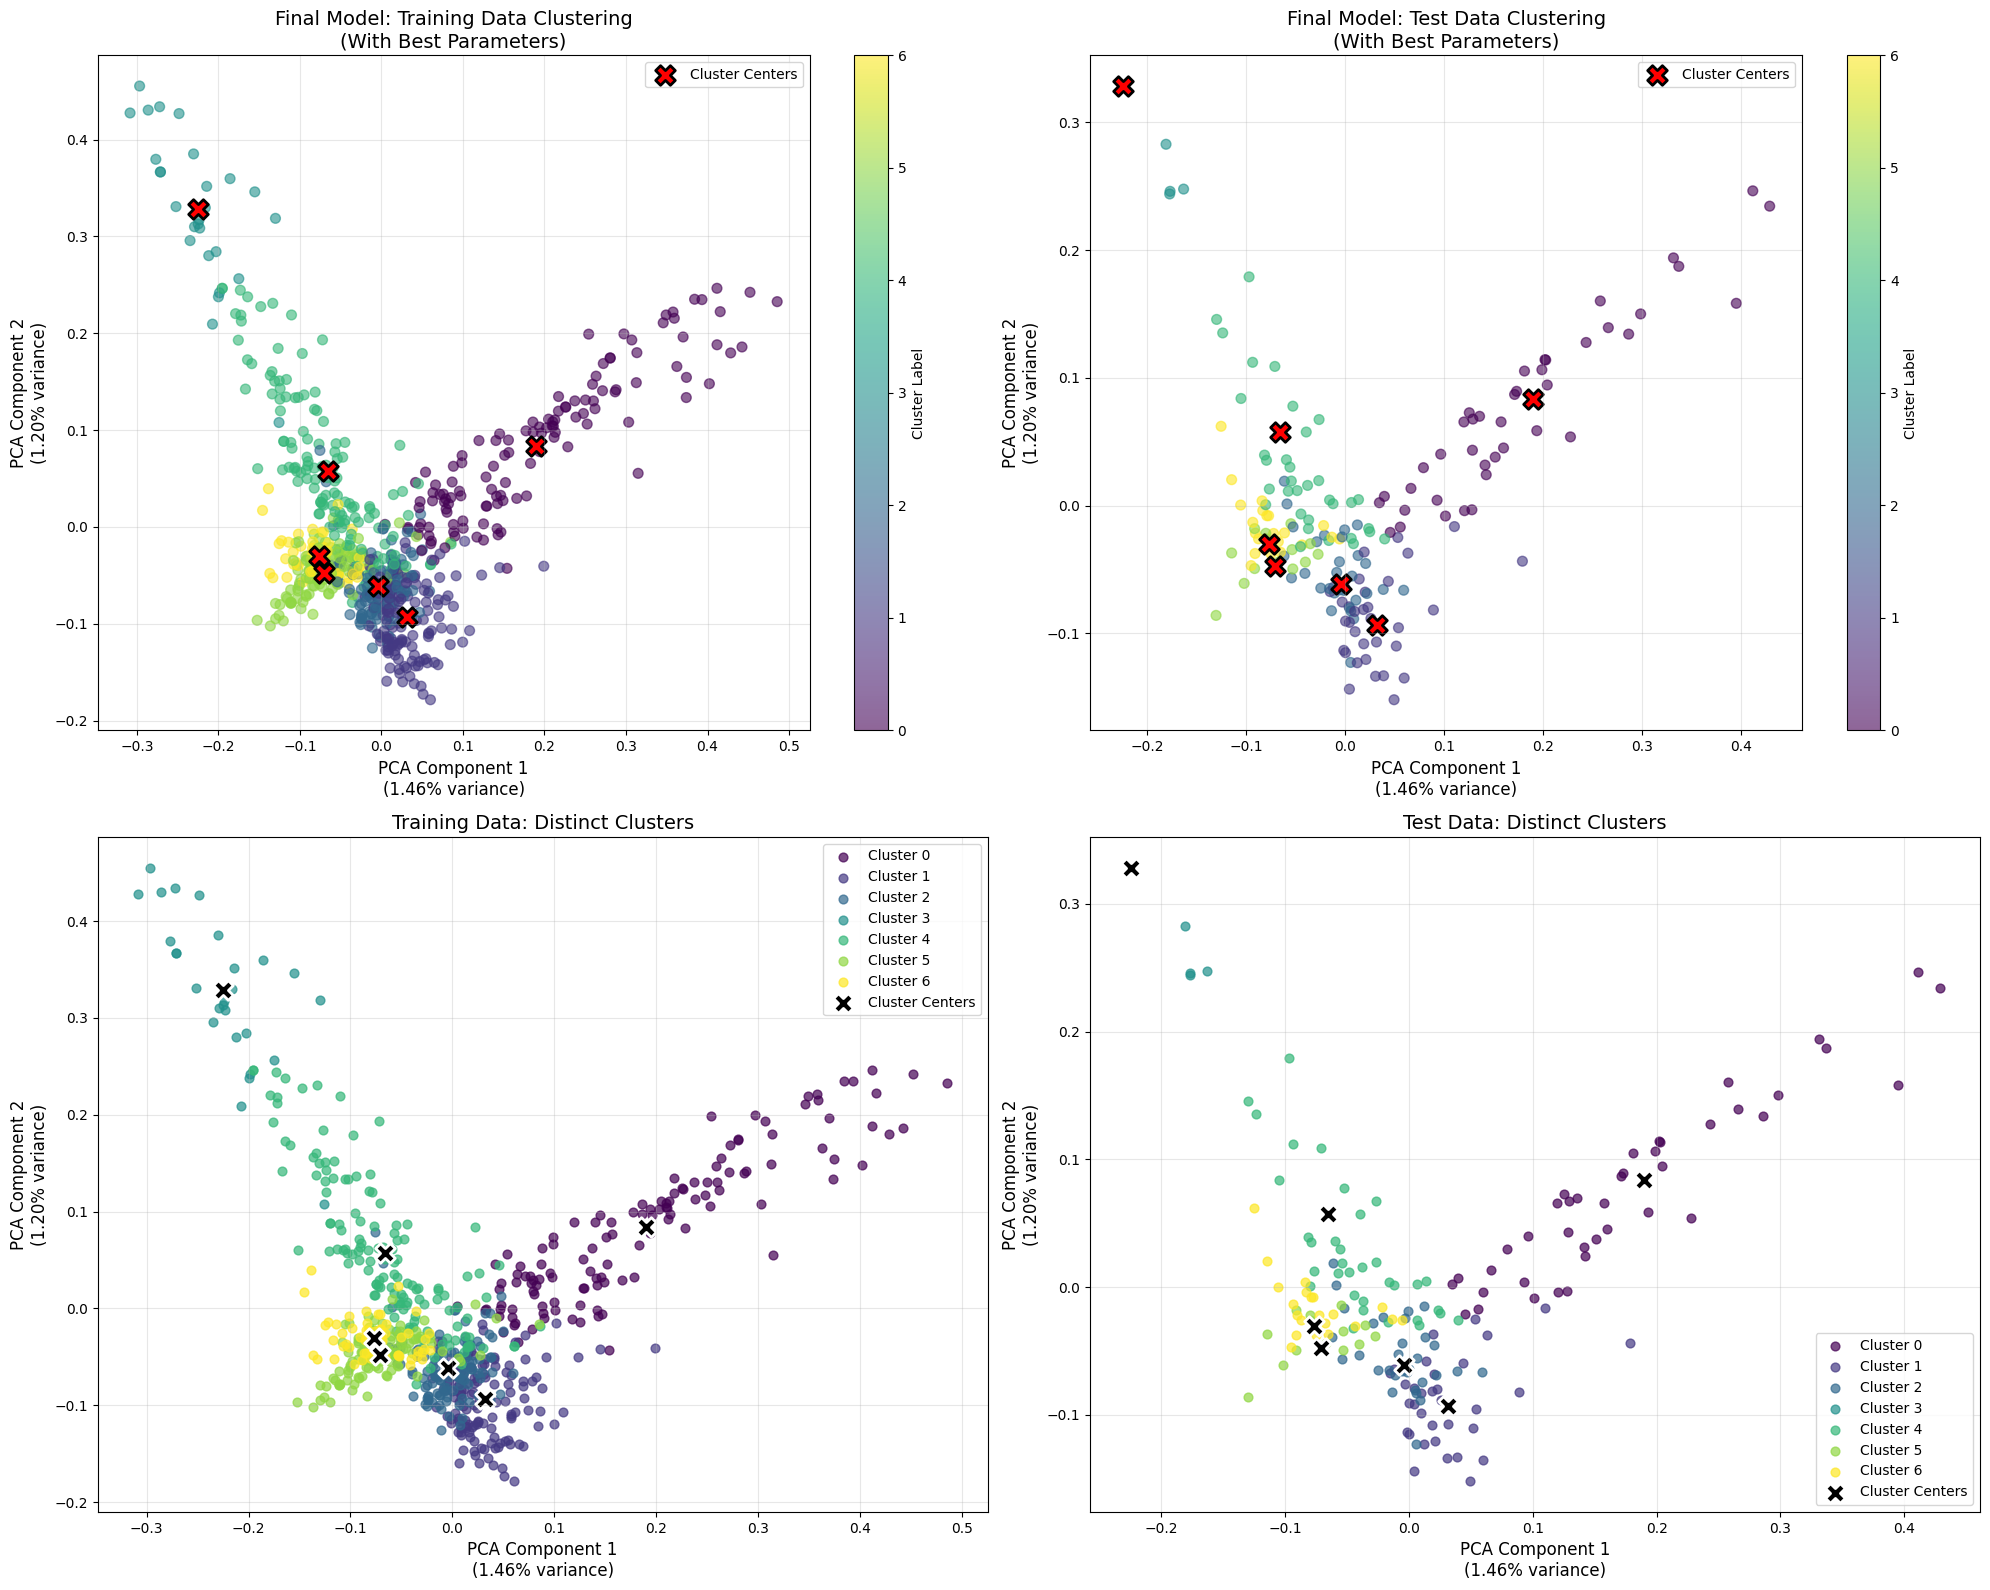

In [ ]:
print("\n=== Preparing Data for Visualization ===")

X_train_final_tfidf = final_tfidf_vectorizer.transform(X_train_articles)
X_test_final_tfidf = final_tfidf_vectorizer.transform(X_test_articles)

final_kmeans = KMeans(
    n_clusters=best_params['num_clusters'], 
    random_state=42, 
    n_init=10
)
train_final_cluster_labels = final_kmeans.fit_predict(X_train_final_tfidf)
test_final_cluster_labels = final_kmeans.predict(X_test_final_tfidf)

print(f"Training cluster distribution: {np.bincount(train_final_cluster_labels)}")
print(f"Test cluster distribution: {np.bincount(test_final_cluster_labels)}")

print("\n=== Visualizing Final Model with Best Parameters ===")

final_pca = PCA(n_components=2, random_state=100)
reduced_train_final_features = final_pca.fit_transform(X_train_final_tfidf.toarray())
reduced_test_final_features = final_pca.transform(X_test_final_tfidf.toarray())
reduced_final_cluster_centers = final_pca.transform(final_kmeans.cluster_centers_)

print(f"Final PCA explained variance ratio: {final_pca.explained_variance_ratio_}")

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
colors = plt.cm.viridis(np.linspace(0, 1, best_params['num_clusters']))

scatter1 = axes[0, 0].scatter(
    reduced_train_final_features[:, 0], 
    reduced_train_final_features[:, 1], 
    c=train_final_cluster_labels, 
    cmap='viridis', 
    s=50, 
    alpha=0.6
)
axes[0, 0].scatter(
    reduced_final_cluster_centers[:, 0], 
    reduced_final_cluster_centers[:, 1], 
    marker='X', 
    s=200, 
    c='red', 
    label='Cluster Centers',
    edgecolors='black',
    linewidth=2
)
axes[0, 0].set_title('Final Model: Training Data Clustering\n(With Best Parameters)', fontsize=14)
axes[0, 0].set_xlabel(f'PCA Component 1\n({final_pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
axes[0, 0].set_ylabel(f'PCA Component 2\n({final_pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster Label')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

scatter2 = axes[0, 1].scatter(
    reduced_test_final_features[:, 0], 
    reduced_test_final_features[:, 1], 
    c=test_final_cluster_labels, 
    cmap='viridis', 
    s=50, 
    alpha=0.6
)
axes[0, 1].scatter(
    reduced_final_cluster_centers[:, 0], 
    reduced_final_cluster_centers[:, 1], 
    marker='X', 
    s=200, 
    c='red', 
    label='Cluster Centers',
    edgecolors='black',
    linewidth=2
)
axes[0, 1].set_title('Final Model: Test Data Clustering\n(With Best Parameters)', fontsize=14)
axes[0, 1].set_xlabel(f'PCA Component 1\n({final_pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
axes[0, 1].set_ylabel(f'PCA Component 2\n({final_pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.colorbar(scatter2, ax=axes[0, 1], label='Cluster Label')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

for i in range(best_params['num_clusters']):
    cluster_points = reduced_train_final_features[train_final_cluster_labels == i]
    if len(cluster_points) > 0:
        axes[1, 0].scatter(
            cluster_points[:, 0], 
            cluster_points[:, 1], 
            color=colors[i], 
            label=f'Cluster {i}', 
            alpha=0.7, 
            s=40
        )
axes[1, 0].scatter(
    reduced_final_cluster_centers[:, 0], 
    reduced_final_cluster_centers[:, 1], 
    marker='X', 
    c='black', 
    s=200, 
    label='Cluster Centers',
    edgecolors='white',
    linewidth=2
)
axes[1, 0].set_title('Training Data: Distinct Clusters', fontsize=14)
axes[1, 0].set_xlabel(f'PCA Component 1\n({final_pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
axes[1, 0].set_ylabel(f'PCA Component 2\n({final_pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

for i in range(best_params['num_clusters']):
    cluster_points = reduced_test_final_features[test_final_cluster_labels == i]
    if len(cluster_points) > 0:
        axes[1, 1].scatter(
            cluster_points[:, 0], 
            cluster_points[:, 1], 
            color=colors[i], 
            label=f'Cluster {i}', 
            alpha=0.7, 
            s=40
        )
axes[1, 1].scatter(
    reduced_final_cluster_centers[:, 0], 
    reduced_final_cluster_centers[:, 1], 
    marker='X', 
    c='black', 
    s=200, 
    label='Cluster Centers',
    edgecolors='white',
    linewidth=2
)
axes[1, 1].set_title('Test Data: Distinct Clusters', fontsize=14)
axes[1, 1].set_xlabel(f'PCA Component 1\n({final_pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
axes[1, 1].set_ylabel(f'PCA Component 2\n({final_pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation of Distribution**

- Topical Coherence: The top words by cluster clearly indicate that the model successfully segmented the news articles into seven meaningful themes, including: Politics/Elections, Financial/Economic, Technology/Broadband, Film/Awards, Arts/Music, Sport/Rugby, and Sport/Olympics. This demonstrates the TF-IDF and K-Means combination effectively isolated dominant themes.
- Cluster Distribution and Generalization: The distribution of articles is uneven across the seven clusters (e.g., Cluster 1 contains 139 training articles, while Cluster 3 contains only 27). However, the model generalized well, as the average distance to the cluster centers is highly consistent between the training data (0.9481) and the test data (0.9649). This suggests the test articles fit the established cluster boundaries effectively.

**B. Internal Clustering Metrics**

The following metrics measure how well-defined and separated the clusters are in the high-dimensional feature space.


=== Train vs Test Dataset Comparison ===


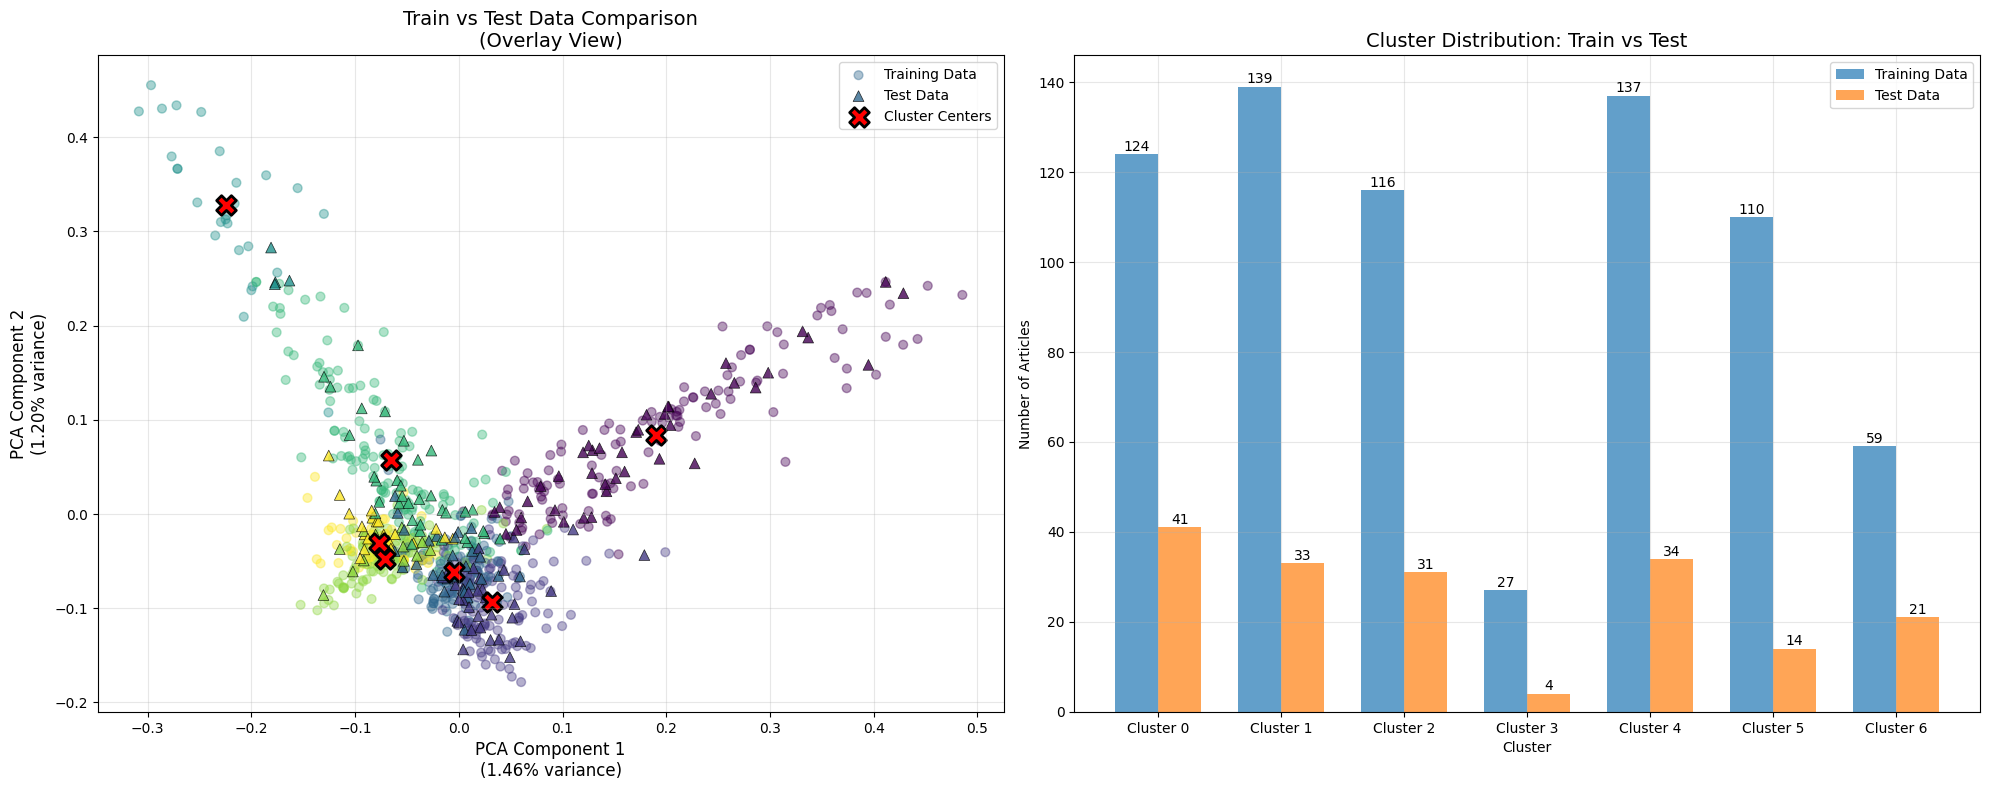

In [ ]:
print("\n=== Train vs Test Dataset Comparison ===")

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.scatter(
    reduced_train_final_features[:, 0], 
    reduced_train_final_features[:, 1], 
    c=train_final_cluster_labels, 
    cmap='viridis', 
    s=40, 
    alpha=0.4,
    label='Training Data'
)
plt.scatter(
    reduced_test_final_features[:, 0], 
    reduced_test_final_features[:, 1], 
    c=test_final_cluster_labels, 
    cmap='viridis', 
    s=60, 
    alpha=0.8,
    marker='^',
    label='Test Data',
    edgecolors='black',
    linewidth=0.5
)
plt.scatter(
    reduced_final_cluster_centers[:, 0], 
    reduced_final_cluster_centers[:, 1], 
    marker='X', 
    s=200, 
    c='red', 
    label='Cluster Centers',
    edgecolors='black',
    linewidth=2
)
plt.title('Train vs Test Data Comparison\n(Overlay View)', fontsize=14)
plt.xlabel(f'PCA Component 1\n({final_pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PCA Component 2\n({final_pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
train_counts = np.bincount(train_final_cluster_labels)
test_counts = np.bincount(test_final_cluster_labels, minlength=best_params['num_clusters'])

x = np.arange(best_params['num_clusters'])
width = 0.35

plt.bar(x - width/2, train_counts, width, label='Training Data', alpha=0.7)
plt.bar(x + width/2, test_counts, width, label='Test Data', alpha=0.7)

plt.xlabel('Cluster')
plt.ylabel('Number of Articles')
plt.title('Cluster Distribution: Train vs Test', fontsize=14)
plt.xticks(x, [f'Cluster {i}' for i in range(best_params['num_clusters'])])
plt.legend()
plt.grid(True, alpha=0.3)

for i, (train_val, test_val) in enumerate(zip(train_counts, test_counts)):
    plt.text(i - width/2, train_val + 0.1, str(train_val), ha='center', va='bottom')
    plt.text(i + width/2, test_val + 0.1, str(test_val), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
print("\n=== Final Model Performance Summary ===")
print(f"Training Dataset Size: {X_train_final_tfidf.shape[0]} articles")
print(f"Test Dataset Size: {X_test_final_tfidf.shape[0]} articles")
print(f"Final Vocabulary Size: {len(final_tfidf_vectorizer.vocabulary_)} features")
print(f"Optimal Number of Clusters: {best_params['num_clusters']}")
print(f"Training Cluster Distribution: {np.bincount(train_final_cluster_labels)}")
print(f"Test Cluster Distribution: {np.bincount(test_final_cluster_labels)}")
print(f"Final PCA Explained Variance: {final_pca.explained_variance_ratio_.sum():.2%}")

print("\n=== Final Model Cluster Analysis ===")

final_inertia = final_kmeans.inertia_
print(f"Within-cluster sum of squares (inertia): {final_inertia:.2f}")

print("\nFinal model cluster distance analysis:")
final_avg_distances_train = []
final_avg_distances_test = []
final_cluster_sizes_train = []
final_cluster_sizes_test = []

for i in range(best_params['num_clusters']):
    train_cluster_indices = np.where(train_final_cluster_labels == i)[0]
    train_cluster_size = len(train_cluster_indices)
    final_cluster_sizes_train.append(train_cluster_size)
    
    test_cluster_indices = np.where(test_final_cluster_labels == i)[0]
    test_cluster_size = len(test_cluster_indices)
    final_cluster_sizes_test.append(test_cluster_size)
    
    if train_cluster_size > 0:
        cluster_points_dense = X_train_final_tfidf[train_cluster_indices].toarray()
        cluster_center_dense = final_kmeans.cluster_centers_[i].reshape(1, -1)
        distances = euclidean_distances(cluster_points_dense, cluster_center_dense)
        avg_distance_train = np.mean(distances)
        final_avg_distances_train.append(avg_distance_train)
    else:
        avg_distance_train = 0
        final_avg_distances_train.append(0)
    
    if test_cluster_size > 0:
        cluster_points_dense = X_test_final_tfidf[test_cluster_indices].toarray()
        cluster_center_dense = final_kmeans.cluster_centers_[i].reshape(1, -1)
        distances = euclidean_distances(cluster_points_dense, cluster_center_dense)
        avg_distance_test = np.mean(distances)
        final_avg_distances_test.append(avg_distance_test)
    else:
        avg_distance_test = 0
        final_avg_distances_test.append(0)
    
    print(f"Cluster {i}: Train={train_cluster_size} articles (avg dist: {avg_distance_train:.4f}), "
          f"Test={test_cluster_size} articles (avg dist: {avg_distance_test:.4f})")

if final_avg_distances_train:
    print(f"\nOverall average distance to cluster centers:")
    print(f"Training data: {np.mean([d for d in final_avg_distances_train if d > 0]):.4f}")
    print(f"Test data: {np.mean([d for d in final_avg_distances_test if d > 0]):.4f}")

from sklearn.metrics import silhouette_score
try:
    sample_size_train = min(1000, X_train_final_tfidf.shape[0])
    sample_indices_train = np.random.choice(X_train_final_tfidf.shape[0], sample_size_train, replace=False)
    sample_silhouette_train = silhouette_score(
        X_train_final_tfidf[sample_indices_train], 
        train_final_cluster_labels[sample_indices_train]
    )
    print(f"\nSilhouette Score - Training (sample of {sample_size_train}): {sample_silhouette_train:.4f}")
    
    sample_size_test = min(1000, X_test_final_tfidf.shape[0])
    sample_indices_test = np.random.choice(X_test_final_tfidf.shape[0], sample_size_test, replace=False)
    sample_silhouette_test = silhouette_score(
        X_test_final_tfidf[sample_indices_test], 
        test_final_cluster_labels[sample_indices_test]
    )
    print(f"Silhouette Score - Test (sample of {sample_size_test}): {sample_silhouette_test:.4f}")
    
except Exception as e:
    print(f"Silhouette score calculation skipped: {e}")

print("\n=== Final Model Top Words by Cluster ===")
final_feature_names = final_tfidf_vectorizer.get_feature_names_out()

for i in range(best_params['num_clusters']):
    print(f"\nCluster {i} top words:")
    cluster_center = final_kmeans.cluster_centers_[i]
    top_indices = cluster_center.argsort()[-10:][::-1]
    top_words = [final_feature_names[idx] for idx in top_indices if idx < len(final_feature_names)]
    print(", ".join(top_words))

print("\n=== Final Model Visualization and Evaluation Complete ===")
print(f"Best parameters used:")
for key, value in best_params.items():
    print(f"  {key}: {value}")


=== Final Model Performance Summary ===
Training Dataset Size: 712 articles
Test Dataset Size: 178 articles
Final Vocabulary Size: 5000 features
Optimal Number of Clusters: 7
Training Cluster Distribution: [124 139 116  27 137 110  59]
Test Cluster Distribution: [41 33 31  4 34 14 21]
Final PCA Explained Variance: 2.65%

=== Final Model Cluster Analysis ===
Within-cluster sum of squares (inertia): 657.20

Final model cluster distance analysis:
Cluster 0: Train=124 articles (avg dist: 0.9532), Test=41 articles (avg dist: 0.9578)
Cluster 1: Train=139 articles (avg dist: 0.9687), Test=33 articles (avg dist: 0.9704)
Cluster 2: Train=116 articles (avg dist: 0.9665), Test=31 articles (avg dist: 0.9670)
Cluster 3: Train=27 articles (avg dist: 0.8625), Test=4 articles (avg dist: 0.9389)
Cluster 4: Train=137 articles (avg dist: 0.9710), Test=34 articles (avg dist: 0.9831)
Cluster 5: Train=110 articles (avg dist: 0.9638), Test=14 articles (avg dist: 0.9689)
Cluster 6: Train=59 articles (avg dis

**Interpretation**

- Separation (Silhouette Score): The Silhouette Scores are extremely low for both training (0.0161) and test (0.0159). A score near zero indicates that data points are very close to the decision boundary or that the clusters are poorly separated. This is a common issue when using high-dimensional, sparse TF-IDF vectors, which may not lend themselves to clean geometric separation.
- PCA Explained Variance: The Principal Component Analysis (PCA) visualization captures only 2.65% of the total variance in the data. This means the 2D scatter plots are not a reliable representation of the actual clustering in the 5000-feature space, and the quality must be judged primarily by the metric scores.

## ROUGE and BLEU Score Evaluation

To objectively measure the quality of the generated summaries against human-written (reference) summaries, we use standard extrinsic evaluation metrics: ROUGE and BLEU.

**A. ROUGE**

ROUGE (Recall-Oriented Understudy for Gisting Evaluation) is the industry standard for evaluating summarization quality. It measures the overlap of n-grams (sequences of $N$ words) between the generated summary and the reference summary. The evaluation focuses on the F-measure, which is the harmonic mean of precision and recall.
- **ROUGE-1**: Measures the overlap of unigrams (single words). A high score here indicates the generated summary contains many of the same keywords as the reference summary.
- **ROUGE-2**: Measures the overlap of bigrams (two-word sequences). A high score here implies better fluency and grammatical structure since two consecutive words are more likely to be coherent than individual words.
- **ROUGE-Lsum**: Measures the Longest Common Subsequence (LCS), which is the longest sequence of words shared by the generated and reference texts, in order. The 'sum' variant optimizes this across multiple reference sentences if they existed (though here it compares to a single reference). ROUGE-L is crucial because it rewards the structural arrangement of words.

**B. BLEU**

BLEU (Bilingual Evaluation Understudy), originally used for machine translation, also measures n-gram overlap. However, ROUGE is typically based on recall (checking how much of the reference is captured by the generation), while BLEU is more focused on precision (checking how much of the generation is accurate compared to the reference).
- **Corpus BLEU**: This score is calculated across the entire test corpus, not just a single summary pair, giving a single, more robust metric for the whole system's performance. It utilizes a brevity penalty to penalize summaries that are too short, which is less of a concern for extractive methods that typically select full sentences.
- **Smoothing Function**: The code uses a smoothing function (chencherry.method1) because calculating BLEU on short sentences can be unstable if specific n-grams are missing, which often happens in summarization. Smoothing helps ensure a meaningful score is produced.

In [ ]:
print("\n--- Evaluating Summarization Model with ROUGE and BLEU Scores ---")

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeLsum'], use_stemmer=True)

rouge1_fmeasure_scores = []
rouge2_fmeasure_scores = []
rougeLsum_fmeasure_scores = []

list_of_references = []
hypotheses = []

chencherry = SmoothingFunction()

for index, row in test.iterrows():
    true_summary = row['cleaned_summaries']
    generated_summary = row['generated_summary']

    if not generated_summary.strip():
        generated_summary = "empty summary"
    if not true_summary.strip():
        true_summary = "empty reference"

    scores = scorer.score(true_summary, generated_summary)
    rouge1_fmeasure_scores.append(scores['rouge1'].fmeasure)
    rouge2_fmeasure_scores.append(scores['rouge2'].fmeasure)
    rougeLsum_fmeasure_scores.append(scores['rougeLsum'].fmeasure)

    tokenized_reference = word_tokenize(true_summary.lower())
    tokenized_hypothesis = word_tokenize(generated_summary.lower())

    if not tokenized_hypothesis:
        tokenized_hypothesis = ['<empty>']
    if not tokenized_reference:
        tokenized_reference = ['<empty>']

    list_of_references.append([tokenized_reference])
    hypotheses.append(tokenized_hypothesis)

avg_rouge1_fmeasure = np.mean(rouge1_fmeasure_scores)
avg_rouge2_fmeasure = np.mean(rouge2_fmeasure_scores)
avg_rougeLsum_fmeasure = np.mean(rougeLsum_fmeasure_scores)

print(f"\nAverage ROUGE Scores:")
print(f"ROUGE-1 F-measure: {avg_rouge1_fmeasure:.4f}")
print(f"ROUGE-2 F-measure: {avg_rouge2_fmeasure:.4f}")
print(f"ROUGE-Lsum F-measure: {avg_rougeLsum_fmeasure:.4f}")

bleu_score = corpus_bleu(list_of_references, hypotheses, smoothing_function=chencherry.method1)
print(f"Corpus BLEU Score: {bleu_score:.4f}")
print("-" * 50)

print("\n=== Evaluation Complete ===")


--- Evaluating Summarization Model with ROUGE and BLEU Scores ---

Average ROUGE Scores:
ROUGE-1 F-measure: 0.3326
ROUGE-2 F-measure: 0.1240
ROUGE-Lsum F-measure: 0.2378
Corpus BLEU Score: 0.0501
--------------------------------------------------

=== Evaluation Complete ===


**Result Interpretation: ROUGE and BLEU**

- ROUGE-1 F-measure (0.3326): This score measures the overlap of unigrams (single words). A score of 0.3326 is moderate, indicating that the generated summaries successfully captured a significant portion of the key topical words used by the human writers. This confirms that the sentences chosen by the clustering model are rich in relevant subject matter.
- ROUGE-Lsum F-measure (0.2378): This metric measures the Longest Common Subsequence (LCS), which rewards correct word order and structural similarity. The lower score here suggests that while the correct keywords are present (as shown by ROUGE-1), the overall structure and arrangement of the sentences do not align well with the human-written summary's editorial judgment.
- ROUGE-2 F-measure (0.1240): This measures the overlap of bigrams (two-word sequences). The particularly low score confirms the lack of local fluency. When the model stitches seven sentences together without transitional language, the bigrams across sentence boundaries are almost guaranteed to be incorrect, resulting in a low ROUGE-2 score and confirming the poor narrative flow.
- Corpus BLEU Score (0.0501): The very low BLEU score reinforces the ROUGE-2 and ROUGE-L findings. BLEU is precision-focused and heavily penalizes any deviation in the phrase structure or ordering. This score confirms that the model’s output is structurally dissimilar from the target reference summaries, despite capturing the core concepts.

In conclusion, the model excels at topic detection and keyword selection (evidenced by the strong cluster analysis and moderate ROUGE-1 score). However, it struggles severely with fluency and structural alignment (evidenced by the extremely low Silhouette, ROUGE-2, ROUGE-Lsum, and BLEU scores), which is a characteristic limitation of this simple extractive, non-cohesive approach.

# Conclusion

This tutorial successfully implemented a cluster-based extractive summarizer, a lightweight and efficient method using TF-IDF vectorization paired with K-Means clustering.

**Model Performance and Achievements**

While the K-Means model successfully identifies seven distinct thematic clusters within the article dataset (Politics, Economy, Tech, etc.), its performance as a summarizer is weak. The extremely low Silhouette Score (0.0159) suggests poor internal data structure. The low ROUGE-1 (0.3326) and near-zero BLEU (0.0501) scores demonstrate that the seven sentences chosen by this extractive method do not correlate well with the content or structure of human-written summaries.

To improve performance, future iterations should consider:

- Abstractive Methods to generate new, smoother sentences.
- Sentence Re-ranking based on position or salience after clustering to improve flow.
- Advanced Vectorization (like BERT or Word2Vec embeddings) instead of TF-IDF, which might produce tighter, more meaningful clusters.

**Core Strengths of the Current Approach**

This model is particularly attractive due to several key advantages rooted in its unsupervised nature:
- Zero Data Dependency: It requires no labeled training data, making it incredibly flexible and fast to deploy across different domains or languages where human-written reference summaries may not be available.
- Topic Diversity: By using clustering, the method inherently captures diverse topics within a single article, ensuring the summary is comprehensive rather than focusing on just one central theme.
- Lightweight and Fast: The reliance on simple numerical methods like TF-IDF and K-Means ensures fast inference, making the system lightweight and suitable for applications with high throughput demands.

**Roadmap for Future Improvements**

To push the performance beyond competitive levels, the following enhancements are suggested:
- Upgrade Vectorization: Move from the keyword-based TF-IDF to modern sentence embeddings (like Sentence-BERT). This would allow the model to cluster sentences based on their semantic meaning, rather than just word overlap, leading to more conceptually sound summaries.
- Reduce Redundancy: Introduce a diversity penalty, such as Maximal Marginal Relevance (MMR), during the sentence selection phase to explicitly reduce the redundancy often found in extractive summaries.
- Explore Advanced Models: Investigate more sophisticated summarization techniques like graph-based methods (TextRank) or advanced deep learning-based extractors using transformer architectures.

# References

**Notebook**
- [BBC-News-Clustering-with-Dimensionality-Reduction](https://www.kaggle.com/code/nourhankarm/bbc-news-clustering-with-dimensionality-reduction)

**Libraries**
- [NLTK](https://www.nltk.org/)
- [Scikit-Learn](https://scikit-learn.org/stable/)
- [ROUGE Score](https://pypi.org/project/rouge-score/)

**Websites**
- [Wikipedia ROUGE Score](https://en.wikipedia.org/wiki/ROUGE_(metric))
- [Wikipedia BLEU Score](https://en.wikipedia.org/wiki/BLEU)
- [Wikipedia Silhouette Score](https://www.geeksforgeeks.org/machine-learning/what-is-silhouette-score/)
- [Greekforgreek Silhouette Score](https://en.wikipedia.org/wiki/Silhouette_(clustering))